# Import

In [2]:
import re
import ast
import time
import pandas as pd
from openai import OpenAI
import yaml
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
from bidi.algorithm import get_display

# Configuration

In [3]:
config_path = os.path.join('..', 'config', 'config.yaml')
PARAMS = yaml.safe_load(open(config_path, 'r', encoding='utf-8'))

TYPES = PARAMS['TYPES']
TYPES = ['drugs','weapon'] 

# Base paths (without {type} placeholder - will be formatted per type)
CSV_PATH_TEMPLATE = os.path.join('..', PARAMS['CSV_PATH'])  # '../cases_csv/{type}'
RESULTS_PATH = os.path.join('..', PARAMS['RESULTS_PATH'])
GT_PATH = os.path.join('..', PARAMS['GT_PATH'])

# Helper function to get path for specific type
def get_csv_path(type_name):
    return CSV_PATH_TEMPLATE.format(type=type_name)

def get_results_path(type_name, subdir=None):
    if subdir:
        return os.path.join(RESULTS_PATH, type_name, subdir)
    return os.path.join(RESULTS_PATH, type_name)

client = OpenAI(api_key=PARAMS['OPENAI_API_KEY'])

ALLOWED = {
    "עובדות המקרה",
    "ראיות לעונש",
    "טיעוני הצדדים",
    "תסקיר שירות מבחן",
    "דיון והכרעה",
    "מידע אחר",
}

# Prompts

In [3]:
FEW_SHOT_EXAMPLES= """
### FEW-SHOT EXAMPLES

#### Example — עובדות המקרה (1)
USER:
כותרת: "כללי"
טקסט:
"ביום 12.3.22 הנאשם נסע ברכב שבו הוחזק סם מסוכן במשקל 3 ק״ג."

ASSISTANT:
עובדות המקרה

#### Example — עובדות המקרה (2)
USER:
כותרת: "רקע"
טקסט:
"הורשעו לפי הודאתם בעבירה של יבוא סם מסוכן לפי סעיף 13."

ASSISTANT:
עובדות המקרה

#### Example — גזר דין (3)
USER:
כותרת: "רקע"
טקסט:
"הנאשם, הורשע על יסוד הודאתו, בעובדות כתב האישום מתוקן13."

ASSISTANT:
עובדות המקרה

---
#### Example — ראיות לעונש (1)
USER:
כותרת: "ראיות לעונש"
טקסט:
"התביעה הציגה חוות דעת של מומחה לפסיכולוגיה פלילית."
ASSISTANT:
ראיות לעונש


#### Example — ראיות לעונש (2)
USER:
כותרת: "מסמכים לעונש"
טקסט:
"ההגנה הציגה מכתב המלצה ממעסיקו של הנאשם."

ASSISTANT:
ראיות לעונש

---

#### Example — טיעוני הצדדים (1)
USER:
כותרת: "טיעוני המאשימה"
טקסט:
"המאשימה מבקשת להשית על הנאשם מאסר בפועל בשל חומרת העבירה."

ASSISTANT:
טיעוני הצדדים

#### Example — טיעוני הצדדים (2)
USER:
כותרת: "טיעוני ההגנה"
טקסט:
"הסנגור טען כי הנאשם נגרר על ידי אחרים ולא יזם את המעשה."

ASSISTANT:
טיעוני הצדדים

---

#### Example — תסקיר שירות מבחן (1)
USER:
כותרת: "תסקיר שירות המבחן"
טקסט:
"שירות המבחן מציין כי הנאשם משתף פעולה עם גורמי הטיפול."

ASSISTANT:
תסקיר שירות מבחן

#### Example — תסקיר שירות מבחן (2)
USER:
כותרת: "תסקיר משלים"
טקסט:
"קצינת המבחן מתארת התקדמות יציבה בתהליך השיקום."

ASSISTANT:
תסקיר שירות מבחן

---

#### Example — דיון והכרעה (1)
USER:
כותרת: "דיון"
טקסט:
"מצאתי כי מתחם הענישה ההולם נע בין 10 ל־18 חודשי מאסר."

ASSISTANT:
דיון והכרעה

#### Example — דיון והכרעה (2)
USER:
כותרת: "קביעת המתחם"
טקסט:
"בהתאם לפסיקה, יש לתת משקל רב לשיקולי הרתעה."

ASSISTANT:
דיון והכרעה

---

#### Example — מידע אחר (1)
USER:
כותרת: "זכות ערעור"
טקסט:
"על פסק דין זה ניתן לערער תוך 45 ימים."

ASSISTANT:
מידע אחר

#### Example — מידע אחר (2)
USER:
כותרת: "נספחים"
טקסט:
"מזכירות בית המשפט תמציא העתק גזר דין לשירות המבחן."

ASSISTANT:
מידע אחר

"""

SYSTEM_PROMPT_TITLE = f"""
אתה מומחה לסיווג כותרות של סעיפים מתוך פסקי דין ישראליים.
עליך לסווג כל כותרת לאחת (ורק אחת) מהקטגוריות הבאות:

1. עובדות המקרה
2. ראיות לעונש
3. טיעוני הצדדים
4. תסקיר שירות מבחן
5. דיון והכרעה
6. מידע אחר

להלן המדריך המלא לסיווג:

────────────────────────────────────────
1. **עובדות המקרה**
תיאור עובדתי של האירוע והנסיבות: מה קרה, כיצד, באילו עבירות הואשם/הודה הנאשם, רקע, מבוא, השתלשלות עניינים, עובדות כתב האישום, וכן פרטים מתוך הסדר טיעון.
**מילות מפתח חזקות:** "כתב האישום", "העובדות", "כללי", "פתח דבר", "עבירה", "רקע", "מבוא", "השתלשלות", "על פי עובדות האישום", "הסדר טיעון", "עובדות כתב האישום".
**הערות:**
- "הסדר טיעון" מסווג כמעט תמיד כאן (אלא אם הכותרת מתמקדת בטענות).
- אם מופיעות טענות ברורות של צדדים → שקול "טיעוני הצדדים".

────────────────────────────────────────
2. **ראיות לעונש**
כל מידע שמוגש לבית המשפט לצורך קביעת העונש: עבר פלילי, חוות דעת, עדי אופי, מסמכים, נתוני תעסוקה, נסיבות חיים בהקשר ראייתי.
**מילות מפתח:** "ראיות לעונש", "הרשעות קודמות", "עבר פלילי", "חוות דעת", "מכתבים", "מסמכים", "תעסוקה", "מוצגים".
**הערה:** אם הכותרת עוסקת בראיה עצמה – ולא בטענות – היא משתייכת לכאן.

────────────────────────────────────────
3. **טיעוני הצדדים**
כותרות המציגות את טענות התביעה/הגנה, סיכומים, עמדות ענישה, דברי נאשם.
**מילות מפתח:** "טיעוני המאשימה", "טיעוני ההגנה", "דברי הנאשם", "עותרת", "מבקשת", "טוען", "סיכומים", "הטיעונים לעונש", "תגובה לעונש".
**אינדיקציות חזקות:** הופעת גורמים מדברים — "ב\"כ המאשימה", "הסנגור טען", "המאשימה מבקשת", "הנאשם אומר".

────────────────────────────────────────
4. **תסקיר שירות מבחן**
כל טקסט המופק ע"י שירות המבחן. כולל תסקיר רגיל, תצהירי נפגעי העבירה, משלים או הערכות שיקום.
**מילות מפתח:** "תסקיר", "תסקירים", "שירות המבחן", "קצינת מבחן", "חוות דעת הממונה", "התרשמות".
**הערה:** כמעט כל אזכור מפורש ל"תסקיר" → שייך לכאן.

────────────────────────────────────────
5. **דיון והכרעה**
חלק משפטי-שיפוטי: ניתוח הלכתי, קביעת מתחם ענישה, קביעת מתחם העונש ההולם, דיון בשיקולים, הפניות לפסיקה, קביעות השופט ומסקנות לגבי העונש.
**מילות מפתח:** "דיון", "הכרעה", "מתחם הענישה", "השיקולים","מתחם העונש ההולם", "מצאתי", "סבורני", "עליי לקבוע", "העונש המתאים", "סוף דבר".
**אינדיקציות חזקות:**
- דיבור בגוף ראשון יחיד של השופט: "מצאתי", "הגעתי למסקנה".
- ניתוח משפטי, הפניות לע"פ/בע"פ, מתחמי ענישה, שיקולי שיקום/הרתעה.
**לא נחשב דיון והכרעה:** תיאור עונש שהוטל *בעבר* או במסגרת עובדות המקרה; או טענות הצדדים.

────────────────────────────────────────
6. **מידע אחר**
כל תוכן טכני/פרוצדורלי שאינו חלק מהותי של פסק הדין.
דוגמאות: "זכות ערעור", מידע מזהה (שמות נאשמים/בא כוח), כותרות ריקות, מידע מנהלי.
**להשתמש בזה רק אם אין התאמה ממשית לאף קטגוריה.**

────────────────────────────────────────
## כללי רצף והיררכיה בין קטגוריות (חובה!)

פסקי דין בישראל כמעט תמיד בנויים בסדר הבא:

1. מידע אחר (אם קיים)  
2. עובדות המקרה  
3-5. ראיות לעונש, טיעוני הצדדים, תסקיר שירות מבחן (בכל סדר)
6. דיון והכרעה  

**אסור לחזור אחורה בסדר!**  
לדוגמה:
אם הפסקה הקודמת היא "עובדות" → הסיווג הנוכחי **לא יכול** להיות "דיון והכרעה".  
אם הפסקה הקודמת היא "דיון והכרעה" → גם הנוכחית חייבת להיות "דיון והכרעה".  

החריג היחיד: "מידע אחר" יכול להופיע גם בסוף (למשל: זכות ערעור).

────────────────────────────────────────

## דוגמאות של סיווג 

{FEW_SHOT_EXAMPLES}

────────────────────────────────────────

### פורמט פלט:
החזר **אך ורק** אחת מהמחרוזות הבאות:
"עובדות המקרה" | "ראיות לעונש" | "טיעוני הצדדים" | "תסקיר שירות מבחן" | "דיון והכרעה" | "מידע אחר"

אסור להחזיר כל הסבר, נימוק או טקסט נוסף.
"""



SYSTEM_PROMPT_TEXT = f"""
אתה מומחה לסיווג משפטים ופסקאות מתוך פסקי דין ישראליים.
עליך לסווג כל משפט/פסקה לאחת (ורק אחת) מהקטגוריות הבאות:

1. עובדות המקרה
2. ראיות לעונש
3. טיעוני הצדדים
4. תסקיר שירות מבחן
5. דיון והכרעה
6. מידע אחר

להלן המדריך המלא לסיווג:

────────────────────────────────────────
1. **עובדות המקרה**
תיאור עובדתי של האירוע והנסיבות: מה קרה, כיצד, באילו עבירות הואשם/הודה הנאשם, רקע, מבוא, השתלשלות עניינים, עובדות כתב האישום, וכן פרטים מתוך הסדר טיעון.
**מילות מפתח חזקות:** "כתב האישום", "העובדות", "כללי", "פתח דבר", "עבירה", "רקע", "מבוא", "השתלשלות", "על פי עובדות האישום", "הסדר טיעון", "עובדות כתב האישום".
**הערות:**
- "הסדר טיעון" מסווג כמעט תמיד כאן (אלא אם הכותרת מתמקדת בטענות).
- אם מופיעות טענות ברורות של צדדים → שקול "טיעוני הצדדים".

────────────────────────────────────────
2. **ראיות לעונש**
כל מידע שמוגש לבית המשפט לצורך קביעת העונש: עבר פלילי, חוות דעת, עדי אופי, מסמכים, נתוני תעסוקה, נסיבות חיים בהקשר ראייתי.
**מילות מפתח:** "ראיות לעונש", "הרשעות קודמות", "עבר פלילי", "חוות דעת", "מכתבים", "מסמכים", "תעסוקה", "מוצגים".
**הערה:** אם הכותרת עוסקת בראיה עצמה – ולא בטענות – היא משתייכת לכאן.

────────────────────────────────────────
3. **טיעוני הצדדים**
כותרות המציגות את טענות התביעה/הגנה, סיכומים, עמדות ענישה, דברי נאשם.
**מילות מפתח:** "טיעוני המאשימה", "טיעוני ההגנה", "דברי הנאשם", "עותרת", "מבקשת", "טוען", "סיכומים", "הטיעונים לעונש", "תגובה לעונש".
**אינדיקציות חזקות:** הופעת גורמים מדברים — "ב\"כ המאשימה", "הסנגור טען", "המאשימה מבקשת", "הנאשם אומר".

────────────────────────────────────────
4. **תסקיר שירות מבחן**
כל טקסט המופק ע"י שירות המבחן. כולל תסקיר רגיל, תצהירי נפגעי העבירה, משלים או הערכות שיקום.
**מילות מפתח:** "תסקיר", "תסקירים", "שירות המבחן", "קצינת מבחן", "חוות דעת הממונה", "התרשמות".
**הערה:** כמעט כל אזכור מפורש ל"תסקיר" → שייך לכאן.

────────────────────────────────────────
5. **דיון והכרעה**
חלק משפטי-שיפוטי: ניתוח הלכתי, קביעת מתחם ענישה, קביעת מתחם העונש ההולם, דיון בשיקולים, הפניות לפסיקה, קביעות השופט ומסקנות לגבי העונש.
**מילות מפתח:** "דיון", "הכרעה", "מתחם הענישה", "השיקולים","מתחם העונש ההולם", "מצאתי", "סבורני", "עליי לקבוע", "העונש המתאים", "סוף דבר".
**אינדיקציות חזקות:**
- דיבור בגוף ראשון יחיד של השופט: "מצאתי", "הגעתי למסקנה".
- ניתוח משפטי, הפניות לע"פ/בע"פ, מתחמי ענישה, שיקולי שיקום/הרתעה.
**לא נחשב דיון והכרעה:** תיאור עונש שהוטל *בעבר* או במסגרת עובדות המקרה; או טענות הצדדים.

────────────────────────────────────────
6. **מידע אחר**
כל תוכן טכני/פרוצדורלי שאינו חלק מהותי של פסק הדין.
דוגמאות: "זכות ערעור", מידע מזהה (שמות נאשמים/בא כוח), כותרות ריקות, מידע מנהלי.
**להשתמש בזה רק אם אין התאמה ממשית לאף קטגוריה.**

────────────────────────────────────────
## כללי רצף והיררכיה בין קטגוריות (חובה!)

פסקי דין בישראל כמעט תמיד בנויים בסדר הבא:

1. מידע אחר (אם קיים)  
2. עובדות המקרה  
3-5. ראיות לעונש, טיעוני הצדדים, תסקיר שירות מבחן (בכל סדר)
6. דיון והכרעה  

**אסור לחזור אחורה בסדר!**  
לדוגמה:
אם הפסקה הקודמת היא "עובדות" → הסיווג הנוכחי **לא יכול** להיות "דיון והכרעה".  
אם הפסקה הקודמת היא "דיון והכרעה" → גם הנוכחית חייבת להיות "דיון והכרעה".  

החריג היחיד: "מידע אחר" יכול להופיע גם בסוף (למשל: זכות ערעור).

────────────────────────────────────────

## דוגמאות של סיווג 

{FEW_SHOT_EXAMPLES}

────────────────────────────────────────

### פורמט פלט:
החזר **אך ורק** אחת מהמחרוזות הבאות:
"עובדות המקרה" | "ראיות לעונש" | "טיעוני הצדדים" | "תסקיר שירות מבחן" | "דיון והכרעה" | "מידע אחר"

אסור להחזיר כל הסבר, נימוק או טקסט נוסף.
"""

SYSTEM_PROMPT_TEXT_TITLE = f"""
אתה מומחה לסיווג טקסטים משפטיים מפסקי דין ישראליים.
אתה מקבל:
- כותרת נוכחית
- טקסט נוכחי
- הסיווג, הכותרת והטקסט של הפסקה/משפט הקודם

מטרתך: לסווג את הכותרת והטקסט הנוכחי לאחת (ורק אחת) מהקטגוריות להלן, תוך שימוש בכללי עקביות בין סעיפים.

────────────────────────────────────────
### הקטגוריות:

1. עובדות המקרה  
2. ראיות לעונש  
3. טיעוני הצדדים  
4. תסקיר שירות מבחן  
5. דיון והכרעה  
6. מידע אחר  

────────────────────────────────────────
### כללים חשובים מאוד (חריגים ומגבלות)

1. **אם הסיווג הקודם ריק ("")**, ברוב המקרים הכותרת הנוכחית תהיה **"עובדות המקרה"**,  
   אלא אם יש סימנים מובהקים לקטגוריה אחרת.  
   **לא ייתכן "דיון והכרעה" כקטגוריה ראשונה.**

2. **"עובדות המקרה" מופיע רק בתחילת המסמך.**  
   אם הסיווג הקודם *אינו* "עובדות המקרה" →  
   **אין לסווג את הנוכחי כ"עובדות המקרה"**, גם אם זה נראה דומה.

3. **אם הסיווג הקודם היה "עובדות המקרה"**,  
   הסיווג הנוכחי **לא יכול להיות** "דיון והכרעה".

4. **הקטגוריה הקודמת אינה ברירת מחדל!**  
   אין להמשיך אותה אוטומטית — רק אם באמת יש התאמה.

5. **התוכן תמיד גובר על הכותרת** במקרה של סתירה.

6. **בחן רמזים לשוניים ונושאיים**, וקבע לאיזו חטיבה בפסק הדין הסעיף הנוכחי שייך, על בסיס גורם דומיננטי.

────────────────────────────────────────
### תהליך קבלת החלטה (שלב אחר שלב)

#### 1. בדיקה: התאמה בין הכותרת הנוכחית לבין הקודמת  
- אם הכותרת זהה:
  א. בדוק האם התוכן הנוכחי מתאים (במידה מסויימת - לא חייב התאמה 100 אחוז) לאותה כותרת.  
     - אם כן → הסווג יהיה כמו הסיווג הקודם.  
     - אם לא → התעלם מהכותרת ומהקטגוריה הקודמת ועבור לשלב 2.
- אם אינה זהה → עבור לשלב 2.

#### 2. בחינת הכותרת הנוכחית  
בדוק האם הכותרת מצביעה בבירור על קטגוריה מסוימת.  
כותרות מובהקות לדוגמה:  
"טיעונים לעונש", "תסקיר משלים", "כתב האישום","Nתחם העונש ההולם", "מבוא", "כללי", "דיון והכרעה".

#### 3. בחינת התוכן בלבד  
- אם כותרת ותוכן תואמים → סווג לפי הכותרת.  
- אם יש סתירה → התוכן קובע.  
- אם התוכן מייצג חלק ברור במבנה פסק הדין → סווג לפי המשמעות המהותית.

────────────────────────────────────────
להלן המדריך המלא לסיווג:

────────────────────────────────────────
1. **עובדות המקרה**
תיאור עובדתי של האירוע והנסיבות: מה קרה, כיצד, באילו עבירות הואשם/הודה הנאשם, רקע, מבוא, השתלשלות עניינים, עובדות כתב האישום, וכן פרטים מתוך הסדר טיעון.
**מילות מפתח חזקות:** "כתב האישום", "העובדות", "כללי", "פתח דבר", "עבירה", "רקע", "מבוא", "השתלשלות", "על פי עובדות האישום", "הסדר טיעון", "עובדות כתב האישום".
**הערות:**
- "הסדר טיעון" מסווג כמעט תמיד כאן (אלא אם הכותרת מתמקדת בטענות).
- אם מופיעות טענות ברורות של צדדים → שקול "טיעוני הצדדים".

────────────────────────────────────────
2. **ראיות לעונש**
כל מידע שמוגש לבית המשפט לצורך קביעת העונש: עבר פלילי, חוות דעת, עדי אופי, מסמכים, נתוני תעסוקה, נסיבות חיים בהקשר ראייתי.
**מילות מפתח:** "ראיות לעונש", "הרשעות קודמות", "עבר פלילי", "חוות דעת", "מכתבים", "מסמכים", "תעסוקה", "מוצגים".
**הערה:** אם הכותרת עוסקת בראיה עצמה – ולא בטענות – היא משתייכת לכאן.

────────────────────────────────────────
3. **טיעוני הצדדים**
כותרות המציגות את טענות התביעה/הגנה, סיכומים, עמדות ענישה, דברי נאשם.
**מילות מפתח:** "טיעוני המאשימה", "טיעוני ההגנה", "דברי הנאשם", "עותרת", "מבקשת", "טוען", "סיכומים", "הטיעונים לעונש", "תגובה לעונש".
**אינדיקציות חזקות:** הופעת גורמים מדברים — "ב\"כ המאשימה", "הסנגור טען", "המאשימה מבקשת", "הנאשם אומר".

────────────────────────────────────────
4. **תסקיר שירות מבחן**
כל טקסט המופק ע"י שירות המבחן. כולל תסקיר רגיל, תצהירי נפגעי העבירה, משלים או הערכות שיקום.
**מילות מפתח:** "תסקיר", "תסקירים", "שירות המבחן", "קצינת מבחן", "חוות דעת הממונה", "התרשמות".
**הערה:** כמעט כל אזכור מפורש ל"תסקיר" → שייך לכאן.

────────────────────────────────────────
5. **דיון והכרעה**
חלק משפטי-שיפוטי: ניתוח הלכתי, קביעת מתחם ענישה, קביעת מתחם העונש ההולם, דיון בשיקולים, הפניות לפסיקה, קביעות השופט ומסקנות לגבי העונש.
**מילות מפתח:** "דיון", "הכרעה", "מתחם הענישה", "השיקולים","מתחם העונש ההולם", "מצאתי", "סבורני", "עליי לקבוע", "העונש המתאים", "סוף דבר".
**אינדיקציות חזקות:**
- דיבור בגוף ראשון יחיד של השופט: "מצאתי", "הגעתי למסקנה".
- ניתוח משפטי, הפניות לע"פ/בע"פ, מתחמי ענישה, שיקולי שיקום/הרתעה.
**לא נחשב דיון והכרעה:** תיאור עונש שהוטל *בעבר* או במסגרת עובדות המקרה; או טענות הצדדים.

────────────────────────────────────────
6. **מידע אחר**
כל תוכן טכני/פרוצדורלי שאינו חלק מהותי של פסק הדין.
דוגמאות: "זכות ערעור", מידע מזהה (שמות נאשמים/בא כוח), כותרות ריקות, מידע מנהלי.
**להשתמש בזה רק אם אין התאמה ממשית לאף קטגוריה.**


────────────────────────────────────────
## כללי רצף והיררכיה בין קטגוריות (חובה!)

פסקי דין בישראל כמעט תמיד בנויים בסדר הבא:

1. מידע אחר (אם קיים)  
2. עובדות המקרה  
3-5. ראיות לעונש, טיעוני הצדדים, תסקיר שירות מבחן (בכל סדר)
6. דיון והכרעה  

**אסור לחזור אחורה בסדר!**  
לדוגמה:
אם הפסקה הקודמת היא "עובדות" → הסיווג הנוכחי **לא יכול** להיות "דיון והכרעה".  
אם הפסקה הקודמת היא "דיון והכרעה" → גם הנוכחית חייבת להיות "דיון והכרעה".  

החריג היחיד: "מידע אחר" יכול להופיע גם בסוף (למשל: זכות ערעור).


────────────────────────────────────────
### דוגמאות Few-Shot

{FEW_SHOT_EXAMPLES}

────────────────────────────────────────
### פורמט פלט:
החזר אחת בלבד:
"עובדות המקרה" | "ראיות לעונש" | "טיעוני הצדדים" | "תסקיר שירות מבחן" | "דיון והכרעה" | "מידע אחר"

אין להחזיר כל הסבר או ניסוח נוסף.
"""



# Functions

In [ ]:
def ask_gpt_single(title: str, last_class,last_text, SYSTEM_PROMPT) -> str:
    """Query the model for a single title → single category (string)."""
    # Per-item user prompt, very strict
    if SYSTEM_PROMPT == SYSTEM_PROMPT_TEXT:
        user_prompt = f"""
        להלן מידע על הפסקה הקודמת לצורך שמירה על רצף נכון:

        הסיווג הקודם: "{last_class}"
        הטקסט הקודם:
        "{last_text}"

        טקסט לסיווג כעת:
        "{title}"

        עליך לבחור קטגוריה אחת בלבד מתוך הרשימה, לפי כללי ההיררכיה הבאה:

        1. מידע אחר  
        2. עובדות המקרה  
        3. ראיות לעונש  
        4. טיעוני הצדדים  
        5. תסקיר שירות מבחן  
        6. דיון והכרעה  

        כללים מחייבים:
        - אסור לחזור אחורה בהיררכיה.
        - אם הסיווג הקודם גבוה יותר (למשל דיון והכרעה), גם הנוכחי חייב להישאר באותה רמה.
        - "עובדות המקרה" חייב להופיע לפני כל היתר (מלבד מידע אחר).
        - "דיון והכרעה" תמיד נסגר את פסק הדין ולא חוזרים ממנו אחורה.
        - אתה לא יכול לסווג "דיון והכרעה""  אם הופיע בסיווג הקודם עובדות המקרה.
        - "מידע אחר" יכול להופיע גם בסוף (למשל זכות ערעור).

        החזר את שם הסיווג בלבד — ללא כל הסבר.
        """
        resp = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_TEXT},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0
        )
        out = (resp.choices[0].message.content or "").strip()
    else:
        user_prompt = f"""
            להלן מידע על הכותרת הקודמת לצורך שמירה על רצף נכון:

            הסיווג הקודם: "{last_class}"

            טקסט לסיווג כעת:
            "{title}"

            עליך לבחור קטגוריה אחת בלבד מתוך הרשימה, לפי כללי ההיררכיה הבאה:

            1. מידע אחר  
            2. עובדות המקרה  
            3. ראיות לעונש  
            4. טיעוני הצדדים  
            5. תסקיר שירות מבחן  
            6. דיון והכרעה  

            כללים מחייבים:
            - אסור לחזור אחורה בהיררכיה.
            - אם הסיווג הקודם גבוה יותר (למשל דיון והכרעה), גם הנוכחי חייב להישאר באותה רמה.
            - "עובדות המקרה" חייב להופיע לפני כל היתר (מלבד מידע אחר).
            - "דיון והכרעה" תמיד נסגר את פסק הדין ולא חוזרים ממנו אחורה.
            - "מידע אחר" יכול להופיע גם בסוף (למשל זכות ערעור).

            החזר את שם הסיווג בלבד — ללא כל הסבר.
            """


        resp = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_TITLE},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0
        )
        out = (resp.choices[0].message.content or "").strip()

    # Normalize minor quotes/spaces
    out = out.replace('"', '').replace("'", "").strip()

    # If model returned extra text like "Mapped: XXX"
    # try to pull a known category substring
    if out not in ALLOWED:
        for cat in ALLOWED:
            if cat in out:
                out = cat
                break

    # Final guardrail
    if out not in ALLOWED:
        out = "מידע אחר"

    return out


def ask_gpt_title_and_text(title, text ,last_class, last_text, last_title, SYSTEM_PROMPT):
    """Query GPT using both title and text → returns single category."""
    
    user_prompt = f"""

    הסיווג של הפסקה/משפט הקודם הוא:
    "{last_class}"
    הטקסט של הפסקה/משפט הקודם הוא:
    "{last_text}"
    הכותרת של הפסקה הקודמת :
    "{last_title}"
    
    הכותרת של הפסקה/משפט הנוכחי היא:
    "{title}" 

    הטקסט נוכחי:
    "{text}"

    אתה מקבל גם את הסיווג של הטקסט ואתה חייב לשמור על הסדר הבא:
        1. מידע אחר
        2. עובדות המקרה
        3-5. ראיות לעונש, טיעוני הצדדים, תסקיר שירות מבחן
        6. דיון והכרעה

        - לדוגמא אם הסיווג הקודם הוא ראיות לעונש הסיווג הנוכחי לא יכול להיות עובדות המקרה.
        - לא חייב להיות כל אחד מהדברים לפעמים אין מידע אחר או תסקיר שירות מבחן או אין קטגוריות אחרות (עובדות המקרה ודיון והכרעה חייב להיות תמיד!).
שהמילים  שגזר דין, גזירת הדין, מופיעים בכותרת יש 3 מקרים:               
        1. אם הסיווג הקודם היה תסקיר שירות המבחן או ראיות לעונש או טיעוני הצדדים אז הסיווג הנוכי של הכותרת תהיה דיון והכרעה.
        2. אם הסיווג הקודם הוא עובדות המקרה אז הסיווג הנוכחי יהיה עובדות המקרה.
        - לא יכול להיות סיווג קודם עובדות המקרה ואז הסיווג הנוכחי דיון והכרעה.



    """

    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_TEXT_TITLE},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0,
    )

    out = (resp.choices[0].message.content or "").strip()

    # Normalize
    out = out.replace('"', '').replace("'", "").strip()

    # Fix overlong responses
    if out not in ALLOWED:
        for cat in ALLOWED:
            if cat in out:
                out = cat
                break

    # Final fallback
    if out not in ALLOWED:
        out = "מידע אחר"

    return out

def map_titles_row_by_row(df: pd.DataFrame, title_col: str, SYSTEM_PROMPT) -> pd.DataFrame:
    cache = {}  # simple memo to reduce calls for repeated titles
    mapped = []
    df_len = len(df)
    i = 0
    last_class =""
    last_text = ""
    for title in df[title_col].astype(str).tolist():
        if title in cache:
            mapped.append(cache[title])
            i += 1
            print(f"🔁 ({i}/{df_len}) Cached mapping into '{cache[title]}")
            continue

        # retry logic (handles transient API issues)
        attempts = 0
        while True:
            attempts += 1
            try:
                if last_class == "דיון והכרעה":
                    # the rest of the categories will be דיון והכרעה
                    category = "דיון והכרעה"
                    cache[title] = category
                    last_class = category
                    last_text = title
                    mapped.append(category)
                    i += 1
                    print(f"✅ ({i}/{df_len}) Mapped into '{category}'")
                    break
                cat = ask_gpt_single(title, last_class,last_text, SYSTEM_PROMPT)
                last_class = cat
                last_text = title
                cache[title] = cat
                mapped.append(cat)
                i += 1
                print(f"✅ ({i}/{df_len}) Mapped into '{cat}'")
                break
            except Exception as e:
                if attempts >= 3:
                    print(f"❌ Failed on '{title[:50]}...' → defaulting to 'מידע אחר' ({e})")
                    cache[title] = "מידע אחר"
                    mapped.append("מידע אחר")
                    break
                time.sleep(0.8 * attempts)  # simple backoff

    df = df.copy()
    df["mapped_category"] = mapped
    return df


def map_title_and_text_row_by_row(df: pd.DataFrame,
                                  title_col: str,
                                  text_col: str,
                                  SYSTEM_PROMPT) -> pd.DataFrame:
    mapped = []
    df_len = len(df)
    i = 0
    last_class =""
    last_text = ""
    text = ""
    last_title = ""
    for _, row in df.iterrows():

        last_text = text
        title = str(row[title_col])
        text = str(row[text_col])
        # Retry logic
        attempts = 0
        while True:
            attempts += 1
            try:
                if last_class == "דיון והכרעה":
                    # the rest of the categories will be דיון והכרעה
                    category = "דיון והכרעה"
                    last_class = category
                    mapped.append(category)
                    last_title = title
                    i += 1
                    print(f"✅ ({i}/{df_len}) Mapped into '{category}'")
                    break
                else:
                    category = ask_gpt_title_and_text(title, text, last_class, last_text,last_title, SYSTEM_PROMPT)
                    last_class = category
                    mapped.append(category)
                    last_title = title
                    i += 1
                    print(f"✅ ({i}/{df_len}) Mapped into '{category}'")
                    break

            except Exception as e:
                if attempts >= 3:
                    print(f"❌ Failed on row {i+1} — defaulting to 'מידע אחר' ({e})")
                    mapped.append("מידע אחר")
                    break

                time.sleep(0.8 * attempts)  # exponential backoff

    df = df.copy()
    df["mapped_category"] = mapped
    return df


# Run

In [86]:
for SYSTEM_PROMPT in [SYSTEM_PROMPT_TEXT]:
    for type in TYPES:
        Folder_path = get_csv_path(type)  # Use helper function
        i = 0
        for file in os.listdir(Folder_path):
            # if file != "SH-22-05-36033-112.csv":
            #     continue
            df = pd.read_csv(os.path.join(Folder_path, file))
            if SYSTEM_PROMPT == SYSTEM_PROMPT_TEXT:
                title_column = "text"
                case = "only_text"
                df_results = map_titles_row_by_row(df, title_column, SYSTEM_PROMPT)

            if SYSTEM_PROMPT == SYSTEM_PROMPT_TITLE:
                title_column = "part"
                case = "only_title"
                df_results = map_titles_row_by_row(df, title_column, SYSTEM_PROMPT)

            if SYSTEM_PROMPT == SYSTEM_PROMPT_TEXT_TITLE:
                title_column = "part"
                text_column = "text"
                case = "text_and_title"
                df_results = map_title_and_text_row_by_row(df, title_column, text_column, SYSTEM_PROMPT)
                
            out_dir = os.path.join(RESULTS_PATH, type, case)

            os.makedirs(out_dir, exist_ok=True)
            out_path = os.path.join(out_dir, f"{file}")
            df_results.to_csv(out_path, index=False)

            i += 1
            print(f"✅ Saved: {out_path}")
            print(f"Processed {i} files from {len(os.listdir(Folder_path))} in {type} type.")

✅ (1/61) Mapped into 'עובדות המקרה'
✅ (2/61) Mapped into 'עובדות המקרה'
✅ (2/61) Mapped into 'עובדות המקרה'
✅ (3/61) Mapped into 'עובדות המקרה'
✅ (3/61) Mapped into 'עובדות המקרה'
✅ (4/61) Mapped into 'עובדות המקרה'
✅ (4/61) Mapped into 'עובדות המקרה'
✅ (5/61) Mapped into 'עובדות המקרה'
✅ (5/61) Mapped into 'עובדות המקרה'
✅ (6/61) Mapped into 'עובדות המקרה'
✅ (6/61) Mapped into 'עובדות המקרה'
✅ (7/61) Mapped into 'עובדות המקרה'
✅ (7/61) Mapped into 'עובדות המקרה'
✅ (8/61) Mapped into 'עובדות המקרה'
✅ (8/61) Mapped into 'עובדות המקרה'
✅ (9/61) Mapped into 'עובדות המקרה'
✅ (9/61) Mapped into 'עובדות המקרה'
✅ (10/61) Mapped into 'עובדות המקרה'
✅ (10/61) Mapped into 'עובדות המקרה'
✅ (11/61) Mapped into 'עובדות המקרה'
✅ (11/61) Mapped into 'עובדות המקרה'
✅ (12/61) Mapped into 'עובדות המקרה'
✅ (12/61) Mapped into 'עובדות המקרה'
✅ (13/61) Mapped into 'עובדות המקרה'
✅ (13/61) Mapped into 'עובדות המקרה'
✅ (14/61) Mapped into 'עובדות המקרה'
✅ (14/61) Mapped into 'עובדות המקרה'
✅ (15/61) Mapped i

# All results to csv

In [ ]:
for TYPE in TYPES:
    gt_df = pd.read_csv(os.path.join(GT_PATH, f'{TYPE}_combined.csv'))
    path = os.path.join(RESULTS_PATH, TYPE, "only_title")
    title_results = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            title_results = pd.concat([title_results, df], ignore_index=True)

    path = os.path.join(RESULTS_PATH, TYPE, "only_text")
    text_results = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            text_results = pd.concat([text_results, df], ignore_index=True)
            
    path = os.path.join(RESULTS_PATH, TYPE, "text_and_title")
    text_and_title_results = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            text_and_title_results = pd.concat([text_and_title_results, df], ignore_index=True)

    title_results = title_results["mapped_category"].tolist()
    text_results = text_results["mapped_category"].tolist()
    text_and_title_results = text_and_title_results["mapped_category"].tolist()

    # add results to gt_df
    gt_df['title_results'] = title_results
    gt_df['text_results'] = text_results
    gt_df['text_and_title_results'] = text_and_title_results
    # save gt_df
    gt_df.to_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'), index=False)

# Plots

## confusion matrix


==================== Evaluating TYPE: drugs ====================

====== Evaluating: title_results ======


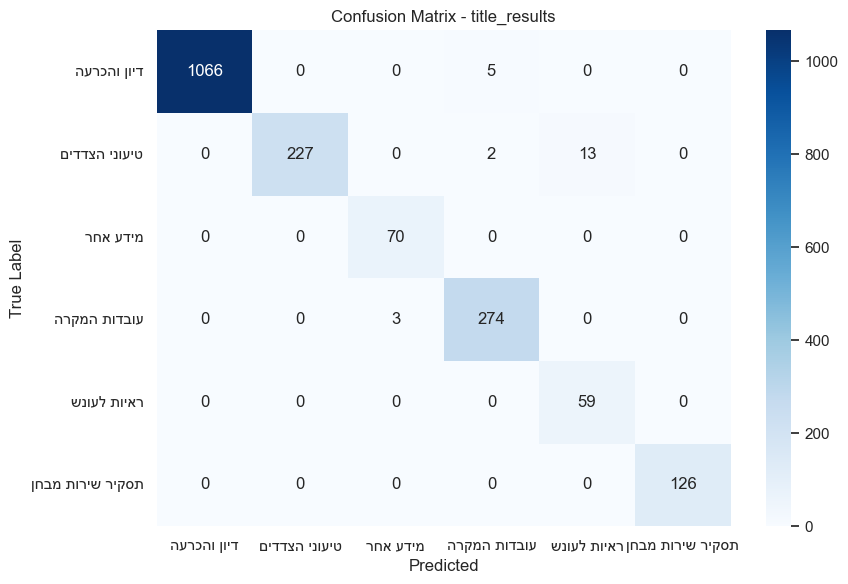


====== Evaluating: text_results ======


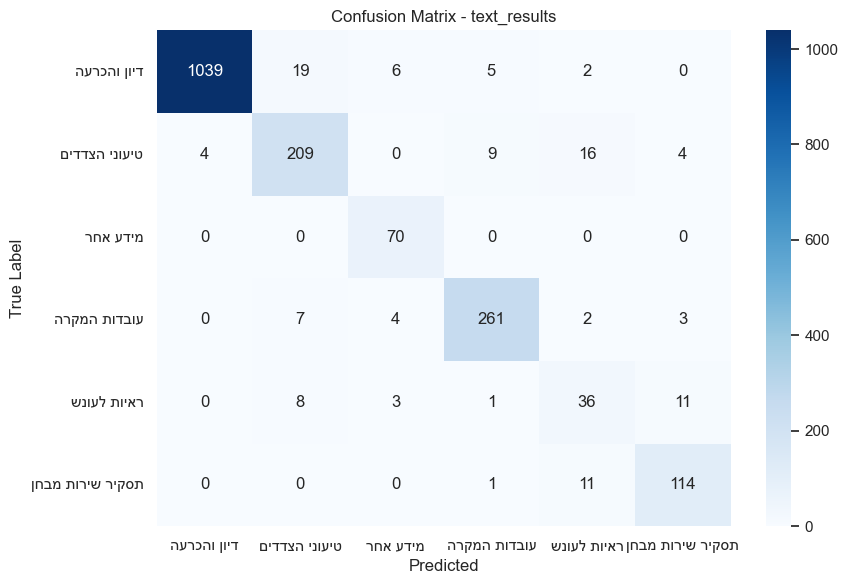


====== Evaluating: text_and_title_results ======


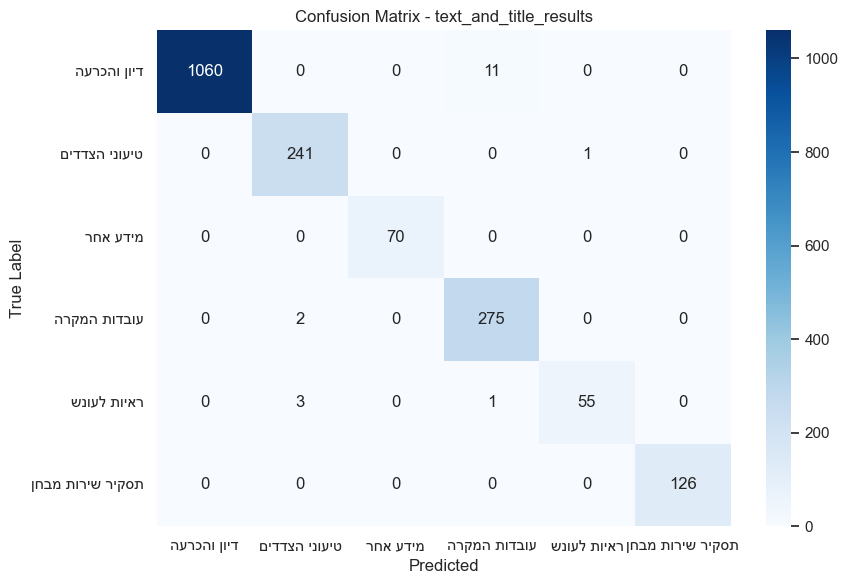


==================== Evaluating TYPE: weapon ====================

====== Evaluating: title_results ======


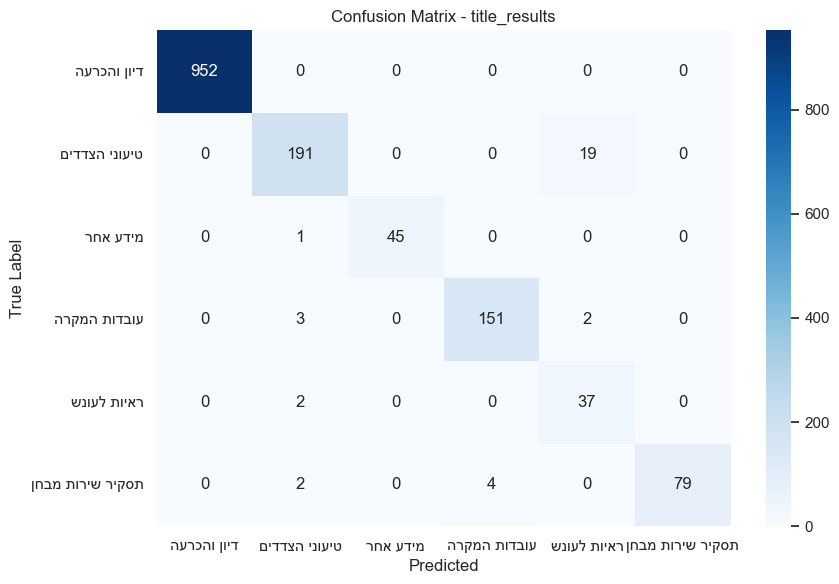


====== Evaluating: text_results ======


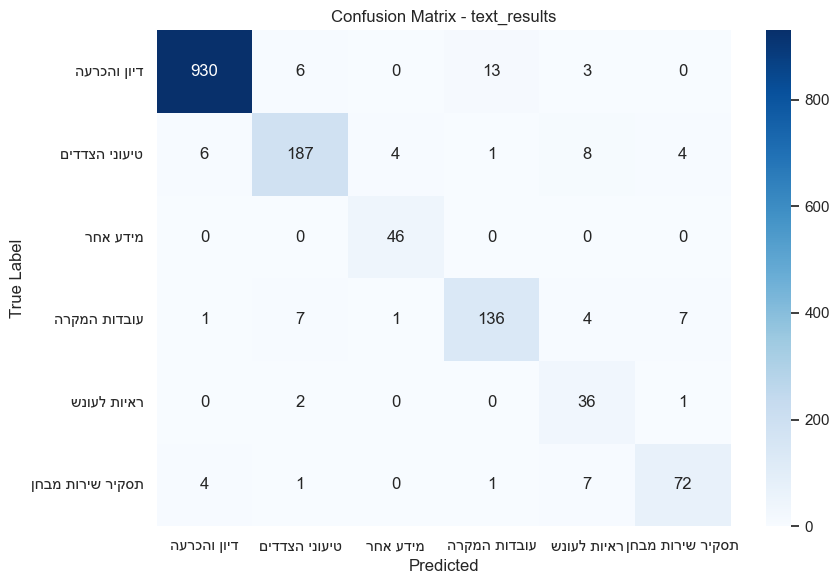


====== Evaluating: text_and_title_results ======


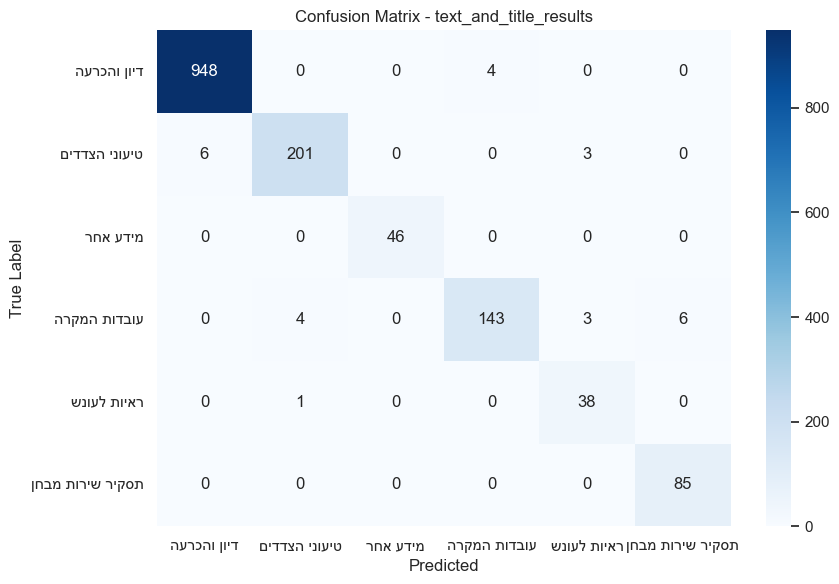

In [5]:
for TYPE in TYPES:
    # -----------------------------
    #  LOAD DATA
    # -----------------------------
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    print(f"\n==================== Evaluating TYPE: {TYPE} ====================")
    # Columns to evaluate
    prediction_columns = ['title_results','text_results', 'text_and_title_results']
    ground_truth_column = 'label'

    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')

    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)

    unique_labels = sorted(results_df[ground_truth_column].unique())
    unique_labels_display = [get_display(label) for label in unique_labels]

    # Save all per-label rows across all models
    all_per_label_rows = []

    # Global metrics storage
    global_metric_rows = []

    sns.set_theme(style="whitegrid")

    # -----------------------------
    # LOOP OVER MODELS
    # -----------------------------
    for col in prediction_columns:
        print(f"\n====== Evaluating: {col} ======")

        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]

        # Accuracy
        acc = accuracy_score(y_true, y_pred)

        # Micro / Macro / Weighted
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        # Save global metrics
        global_metric_rows.append({
            'Input_Type': col,
            'Overall_Accuracy': acc,
            'Micro-F1': micro_f1,
            'Macro-F1': macro_f1,
            'Weighted-F1': weighted_f1
        })

        # -----------------------------
        #  PER-LABEL METRICS
        # -----------------------------
        per_label = []

        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            support = (y_true == label).sum()

            per_label.append({
                'Input_Type': col,
                'Class': label,
                'Class_Display': get_display(label),
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1,
                'Support': support
            })

        # Convert to DataFrame
        per_label_df = pd.DataFrame(per_label)

        # Add to global per-class storage
        all_per_label_rows.append(per_label_df)

        
        # -----------------------------
        # VISUALIZATIONS
        # -----------------------------

        # 1. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        plt.figure(figsize=(9, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                    xticklabels=unique_labels_display, yticklabels=unique_labels_display)
        plt.title(f"Confusion Matrix - {col}")
        plt.xlabel("Predicted")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()




## Count of Each Label

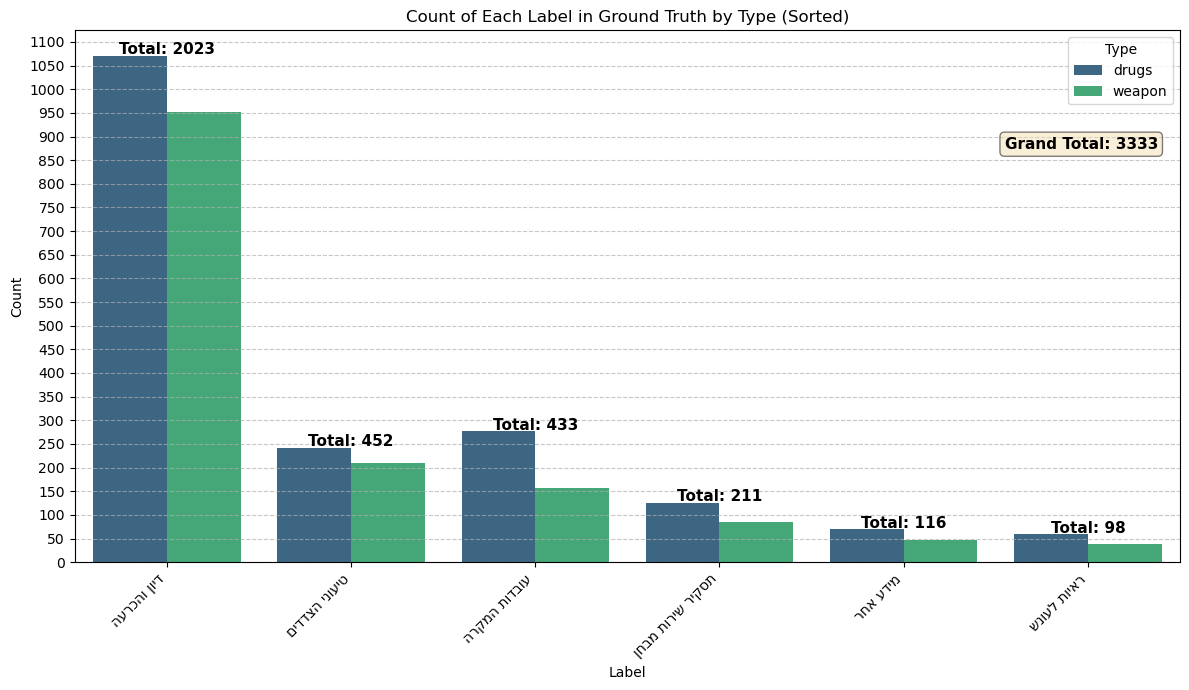

In [4]:
gt_dfs = []
for TYPE in TYPES:
    gt_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    gt_df['type'] = TYPE
    gt_dfs.append(gt_df)
combined_gt_df = pd.concat(gt_dfs, ignore_index=True)

# Calculate counts and sort by total (descending - largest on left)
label_counts = combined_gt_df.groupby('label').size().reset_index(name='total')
label_order = label_counts.sort_values('total', ascending=False)['label'].tolist()

# Create display labels (RTL fix)
combined_gt_df['label_display'] = combined_gt_df['label'].apply(get_display)
label_order_display = [get_display(l) for l in label_order]

# Calculate totals for annotation
totals_per_label = combined_gt_df.groupby('label_display').size().to_dict()

plt.figure(figsize=(12, 7))
ax = sns.countplot(data=combined_gt_df, x='label_display', hue='type', 
                   order=label_order_display, palette='viridis')

# Add horizontal grid lines at y=50 intervals
ax.yaxis.set_major_locator(plt.MultipleLocator(50))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add total annotations on top of bars
for label_display in label_order_display:
    total = totals_per_label.get(label_display, 0)
    x_pos = label_order_display.index(label_display)
    # Get the max height for this label
    max_height = 0
    for p in ax.patches:
        if abs(p.get_x() + p.get_width()/2 - x_pos) < 0.5:
            max_height = max(max_height, p.get_height())
    ax.annotate(f'Total: {total}', (x_pos, max_height + 3), ha='center', fontsize=11, fontweight='bold')

plt.title('Count of Each Label in Ground Truth by Type (Sorted)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add legend with grand total next to it
grand_total = len(combined_gt_df)
legend = plt.legend(title='Type', loc='upper right')
ax.annotate(f'Grand Total: {grand_total}', xy=(0.98, 0.8), xycoords='axes fraction',
             ha='right', va='top', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Per Label Calculation

DRUGS


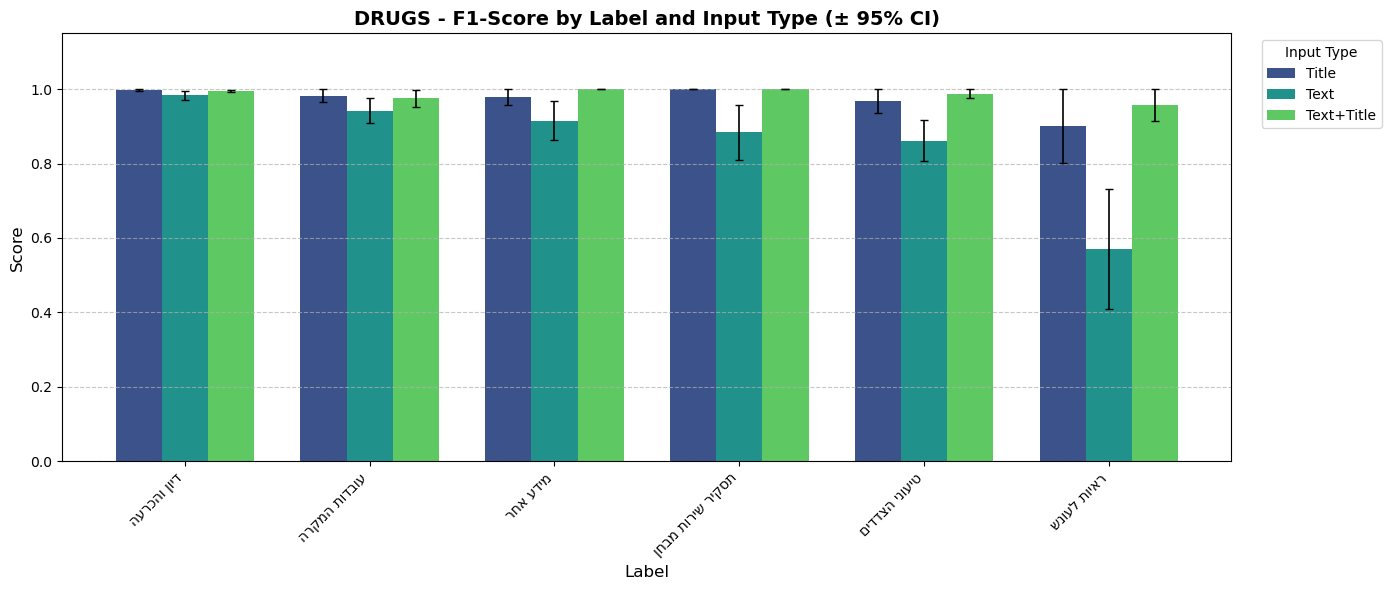

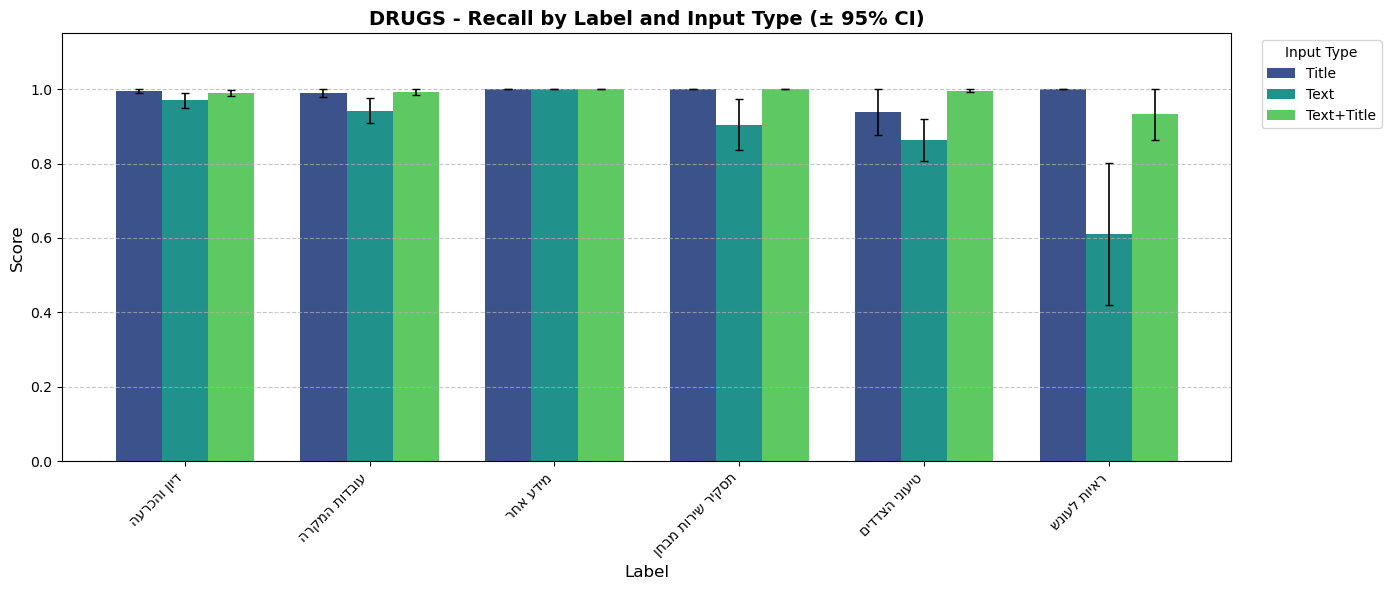

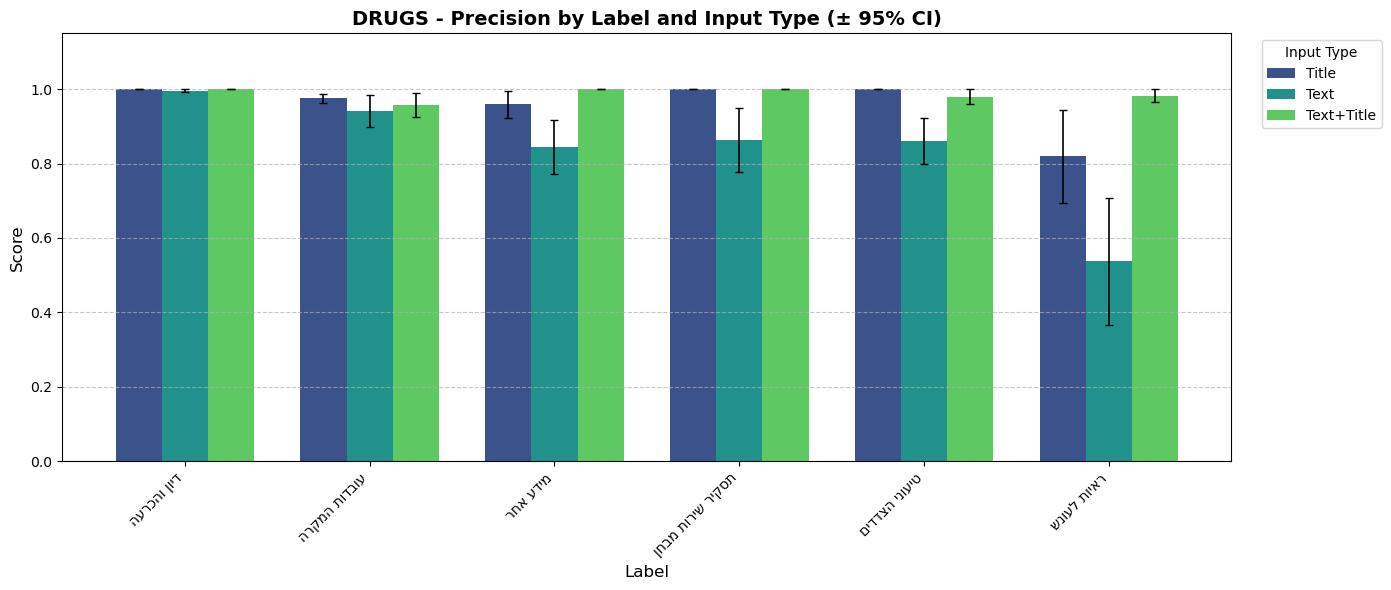

WEAPON


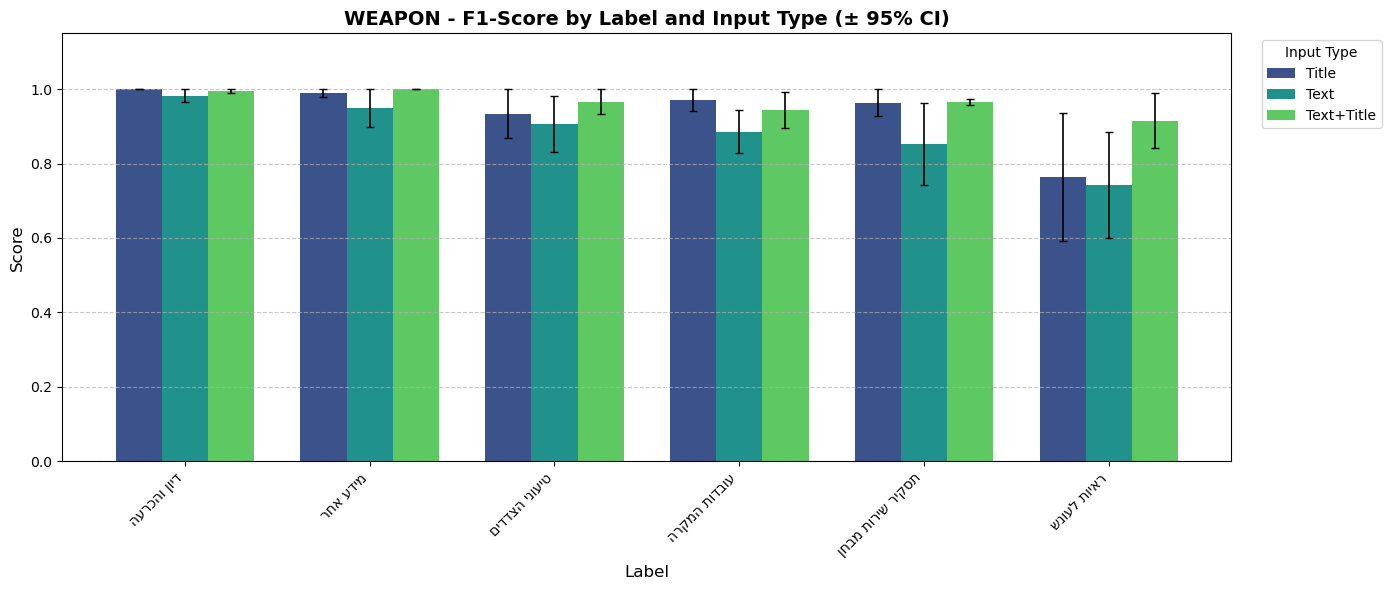

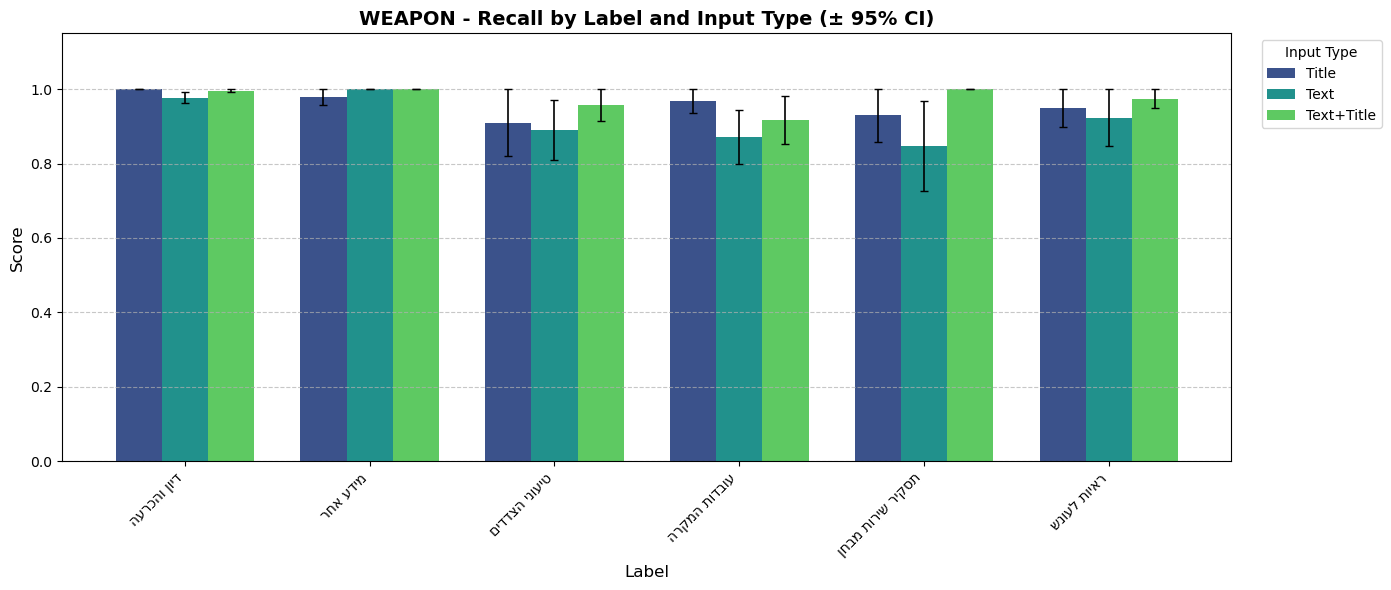

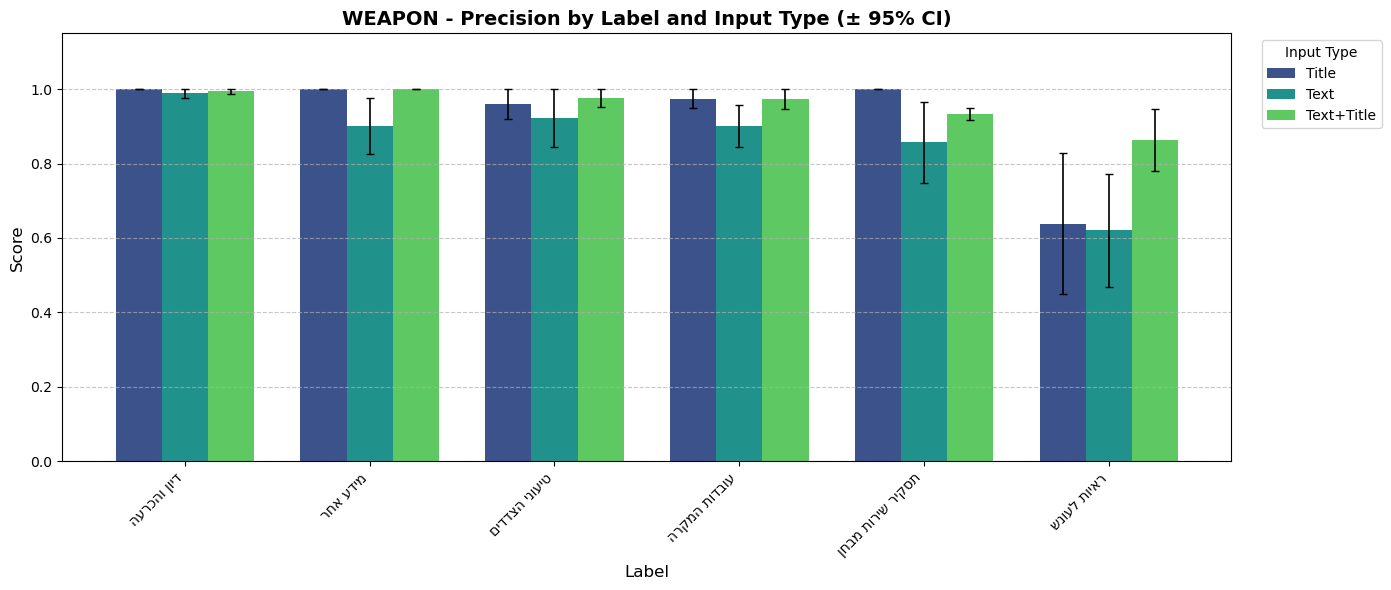

COMBINED (Drugs + Weapon)


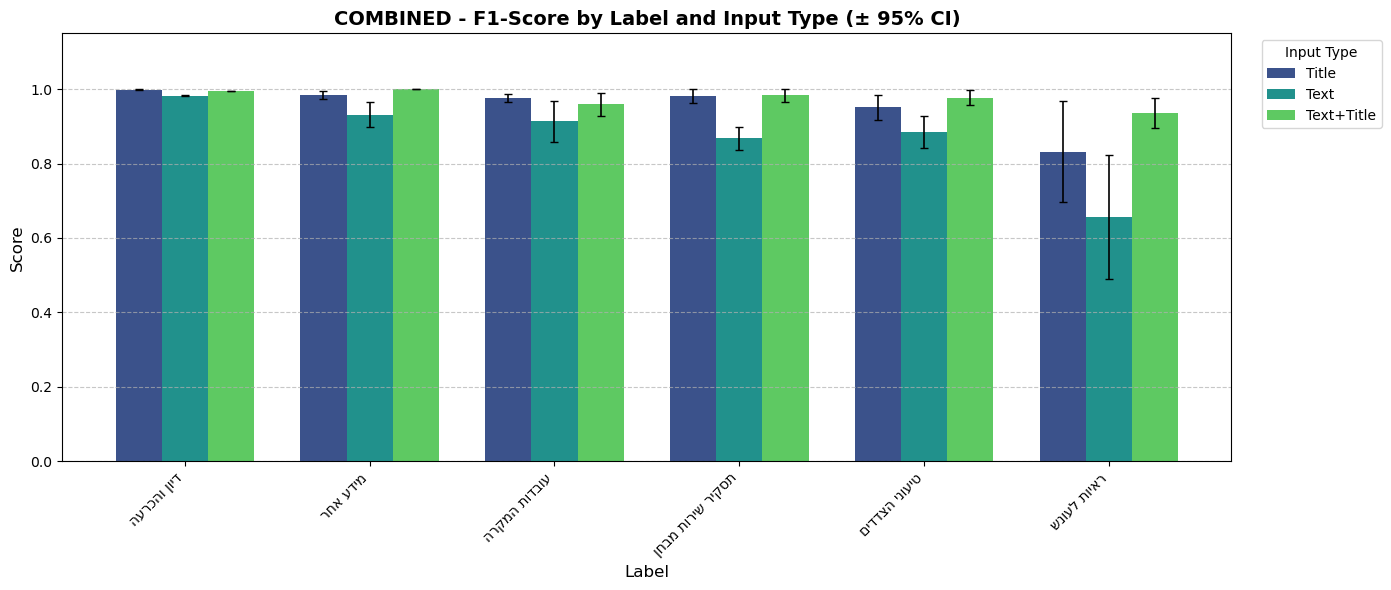

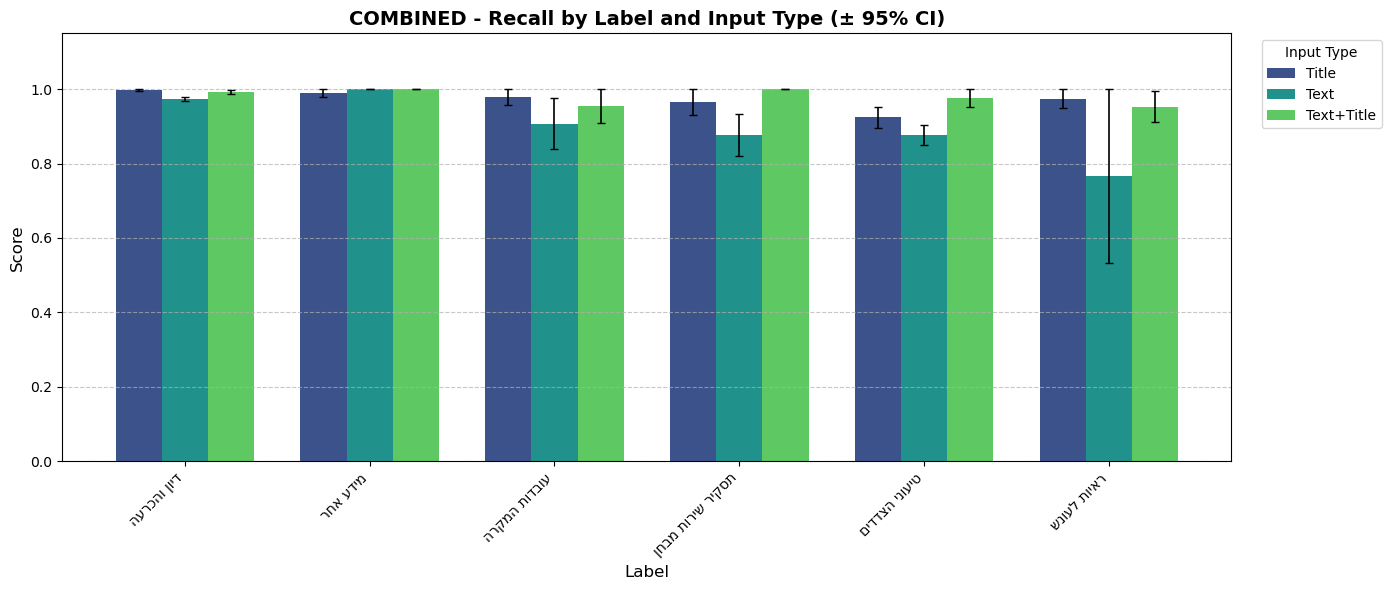

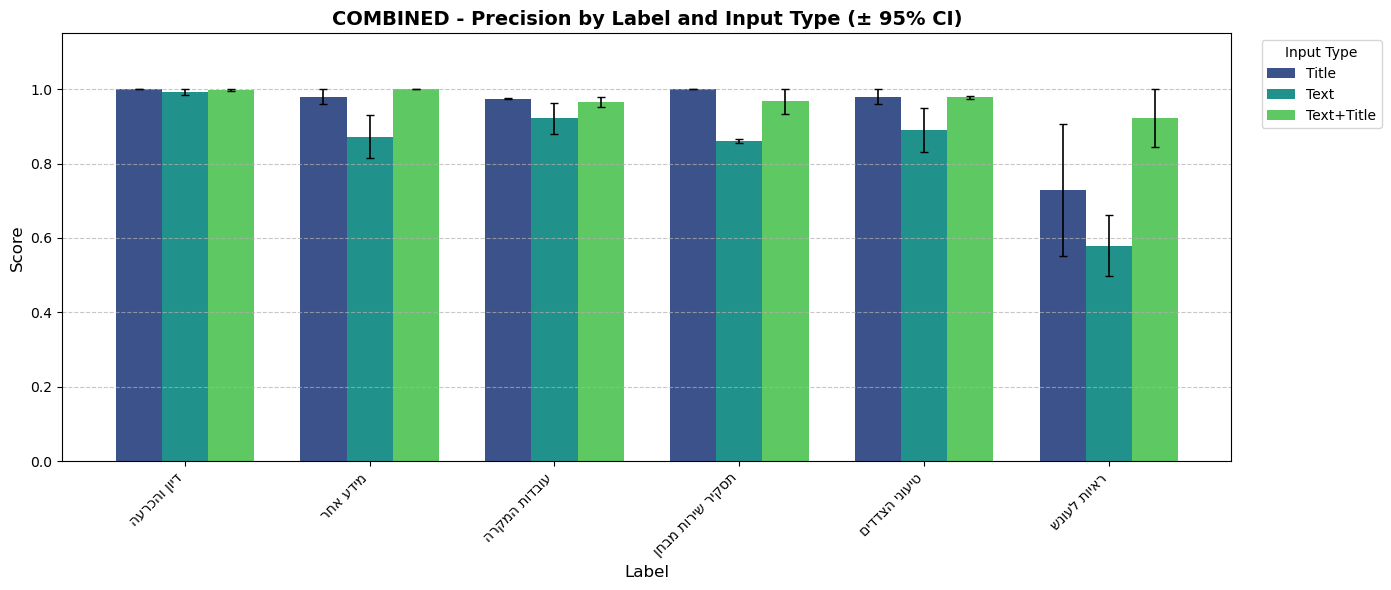

In [8]:
all_metrics = []
all_file_metrics = []  # Per-file metrics for error bars

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    # Get file list for per-file metrics
    path = os.path.join(RESULTS_PATH, TYPE, "only_title")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Overall metrics per label
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            
            input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
            
            all_metrics.append({
                'Type': TYPE,
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            })
        
        # Per-file metrics for error bars
        case = 'only_title' if col == 'title_results' else ('only_text' if col == 'text_results' else 'text_and_title')
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        start_idx = 0
        
        for file in files:
            file_path = os.path.join(RESULTS_PATH, TYPE, case, file)
            if os.path.exists(file_path):
                file_df = pd.read_csv(file_path)
                file_len = len(file_df)
                if file_len > 0:
                    file_y_true = y_true.iloc[start_idx:start_idx + file_len]
                    file_y_pred = y_pred.iloc[start_idx:start_idx + file_len]
                    
                    for label in unique_labels:
                        if (file_y_true == label).sum() > 0:  # Only if label exists in file
                            file_precision = precision_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            file_recall = recall_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            file_f1 = f1_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            
                            all_file_metrics.append({
                                'Type': TYPE,
                                'File': file,
                                'Label': label,
                                'Label_Display': get_display(label),
                                'Input_Type': input_name,
                                'Precision': file_precision,
                                'Recall': file_recall,
                                'F1-Score': file_f1
                            })
                    
                start_idx += file_len

metrics_df = pd.DataFrame(all_metrics)
file_metrics_df = pd.DataFrame(all_file_metrics)

metrics_to_plot = [('F1-Score', 'F1-Score'), ('Recall', 'Recall'), ('Precision', 'Precision')]

# =====================
# DRUGS - 3 plots with 95% CI error bars
# =====================
print("=" * 50)
print("DRUGS")
print("=" * 50)

drugs_df = metrics_df[metrics_df['Type'] == 'drugs']
drugs_file_df = file_metrics_df[file_metrics_df['Type'] == 'drugs']

# Calculate 95% CI from per-file metrics: CI = Z * (std / sqrt(n))
drugs_ci_df = drugs_file_df.groupby(['Label_Display', 'Input_Type']).agg({
    'Precision': ['std', 'count'],
    'Recall': ['std', 'count'],
    'F1-Score': ['std', 'count']
}).reset_index()
drugs_ci_df.columns = ['Label_Display', 'Input_Type', 
                       'Precision_std', 'Precision_n', 
                       'Recall_std', 'Recall_n', 
                       'F1-Score_std', 'F1-Score_n']
drugs_ci_df = drugs_ci_df.fillna(0)
# Calculate 95% CI
drugs_ci_df['Precision_ci'] = Z_95 * drugs_ci_df['Precision_std'] / np.sqrt(drugs_ci_df['Precision_n'].replace(0, 1))
drugs_ci_df['Recall_ci'] = Z_95 * drugs_ci_df['Recall_std'] / np.sqrt(drugs_ci_df['Recall_n'].replace(0, 1))
drugs_ci_df['F1-Score_ci'] = Z_95 * drugs_ci_df['F1-Score_std'] / np.sqrt(drugs_ci_df['F1-Score_n'].replace(0, 1))

drugs_label_order = drugs_df.groupby('Label_Display')['F1-Score'].mean().sort_values(ascending=False).index.tolist()

for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    
    input_order = ['Title', 'Text', 'Text+Title']
    x = np.arange(len(drugs_label_order))
    width = 0.25
    colors = sns.color_palette('viridis', 3)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for label in drugs_label_order:
            row = drugs_df[(drugs_df['Label_Display'] == label) & (drugs_df['Input_Type'] == input_type)]
            ci_row = drugs_ci_df[(drugs_ci_df['Label_Display'] == label) & (drugs_ci_df['Input_Type'] == input_type)]
            mean_val = row[metric_col].values[0] if len(row) > 0 else 0
            ci_val = ci_row[f'{metric_col}_ci'].values[0] if len(ci_row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                       yerr=cis, capsize=3, error_kw={'linewidth': 1.2})
    
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'DRUGS - {metric_name} by Label and Input Type (± 95% CI)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, drugs_label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# =====================
# WEAPON - 3 plots with 95% CI error bars
# =====================
print("=" * 50)
print("WEAPON")
print("=" * 50)

weapon_df = metrics_df[metrics_df['Type'] == 'weapon']
weapon_file_df = file_metrics_df[file_metrics_df['Type'] == 'weapon']

# Calculate 95% CI from per-file metrics
weapon_ci_df = weapon_file_df.groupby(['Label_Display', 'Input_Type']).agg({
    'Precision': ['std', 'count'],
    'Recall': ['std', 'count'],
    'F1-Score': ['std', 'count']
}).reset_index()
weapon_ci_df.columns = ['Label_Display', 'Input_Type', 
                        'Precision_std', 'Precision_n', 
                        'Recall_std', 'Recall_n', 
                        'F1-Score_std', 'F1-Score_n']
weapon_ci_df = weapon_ci_df.fillna(0)
# Calculate 95% CI
weapon_ci_df['Precision_ci'] = Z_95 * weapon_ci_df['Precision_std'] / np.sqrt(weapon_ci_df['Precision_n'].replace(0, 1))
weapon_ci_df['Recall_ci'] = Z_95 * weapon_ci_df['Recall_std'] / np.sqrt(weapon_ci_df['Recall_n'].replace(0, 1))
weapon_ci_df['F1-Score_ci'] = Z_95 * weapon_ci_df['F1-Score_std'] / np.sqrt(weapon_ci_df['F1-Score_n'].replace(0, 1))

weapon_label_order = weapon_df.groupby('Label_Display')['F1-Score'].mean().sort_values(ascending=False).index.tolist()

for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    
    input_order = ['Title', 'Text', 'Text+Title']
    x = np.arange(len(weapon_label_order))
    width = 0.25
    colors = sns.color_palette('viridis', 3)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for label in weapon_label_order:
            row = weapon_df[(weapon_df['Label_Display'] == label) & (weapon_df['Input_Type'] == input_type)]
            ci_row = weapon_ci_df[(weapon_ci_df['Label_Display'] == label) & (weapon_ci_df['Input_Type'] == input_type)]
            mean_val = row[metric_col].values[0] if len(row) > 0 else 0
            ci_val = ci_row[f'{metric_col}_ci'].values[0] if len(ci_row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                       yerr=cis, capsize=3, error_kw={'linewidth': 1.2})
    
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'WEAPON - {metric_name} by Label and Input Type (± 95% CI)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, weapon_label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# =====================
# COMBINED (Drugs + Weapon) - 3 plots with 95% CI error bars
# =====================
print("=" * 50)
print("COMBINED (Drugs + Weapon)")
print("=" * 50)

# Aggregate by Label and Input Type (mean and 95% CI across drugs and weapon)
combined_agg = metrics_df.groupby(['Label_Display', 'Input_Type']).agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
combined_agg.columns = ['Label_Display', 'Input_Type', 
                        'Precision_mean', 'Precision_std', 'Precision_n',
                        'Recall_mean', 'Recall_std', 'Recall_n',
                        'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']
combined_agg = combined_agg.fillna(0)
# Calculate 95% CI
combined_agg['Precision_ci'] = Z_95 * combined_agg['Precision_std'] / np.sqrt(combined_agg['Precision_n'].replace(0, 1))
combined_agg['Recall_ci'] = Z_95 * combined_agg['Recall_std'] / np.sqrt(combined_agg['Recall_n'].replace(0, 1))
combined_agg['F1-Score_ci'] = Z_95 * combined_agg['F1-Score_std'] / np.sqrt(combined_agg['F1-Score_n'].replace(0, 1))

combined_label_order = combined_agg.groupby('Label_Display')['F1-Score_mean'].mean().sort_values(ascending=False).index.tolist()

for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    
    input_order = ['Title', 'Text', 'Text+Title']
    x = np.arange(len(combined_label_order))
    width = 0.25
    colors = sns.color_palette('viridis', 3)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for label in combined_label_order:
            row = combined_agg[(combined_agg['Label_Display'] == label) & (combined_agg['Input_Type'] == input_type)]
            mean_val = row[f'{metric_col}_mean'].values[0] if len(row) > 0 else 0
            ci_val = row[f'{metric_col}_ci'].values[0] if len(row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                       yerr=cis, capsize=3, error_kw={'linewidth': 1.2})
    
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'COMBINED - {metric_name} by Label and Input Type (± 95% CI)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, combined_label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Macro Calculation

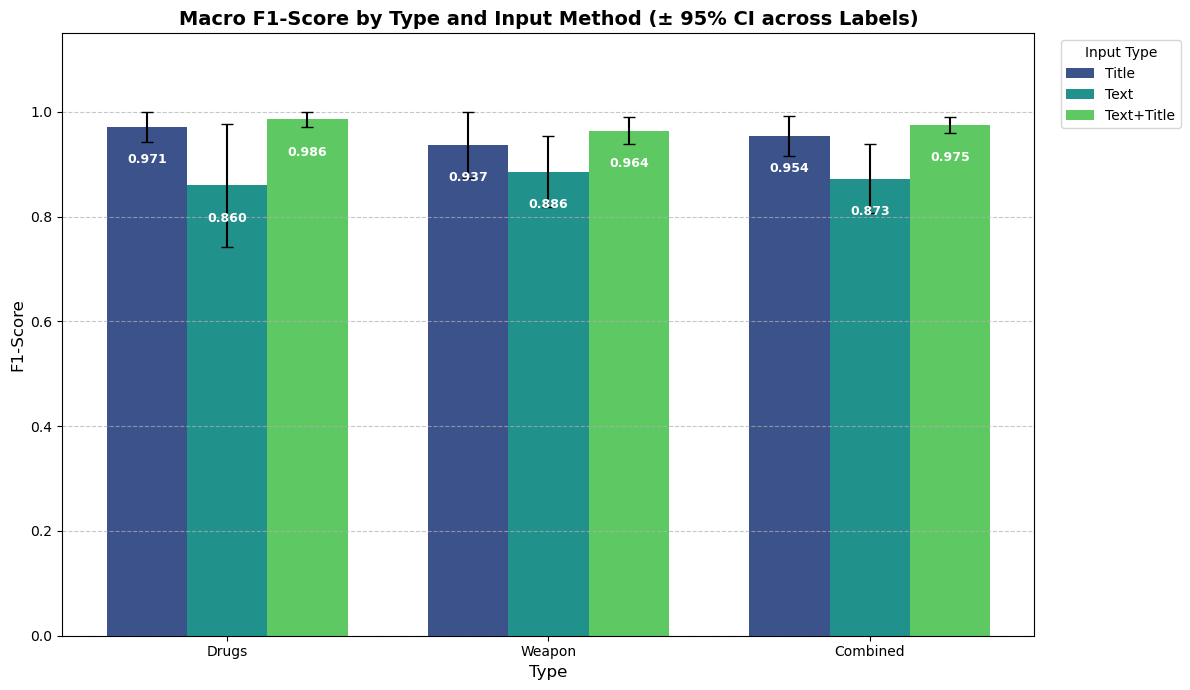

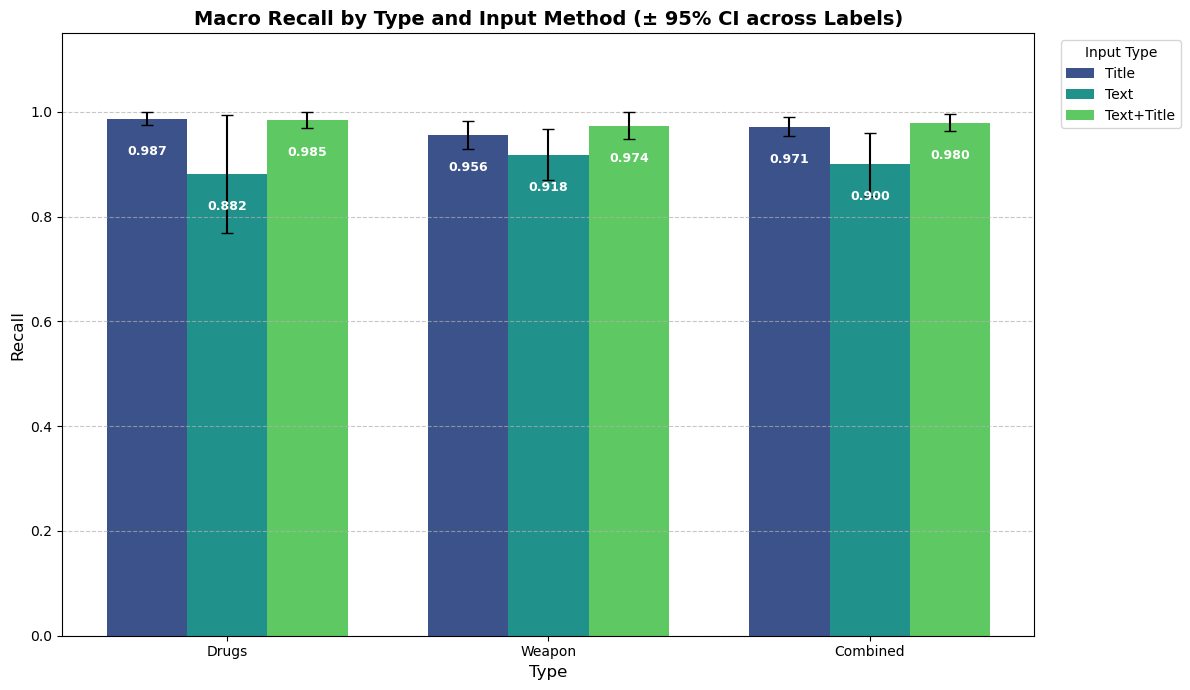

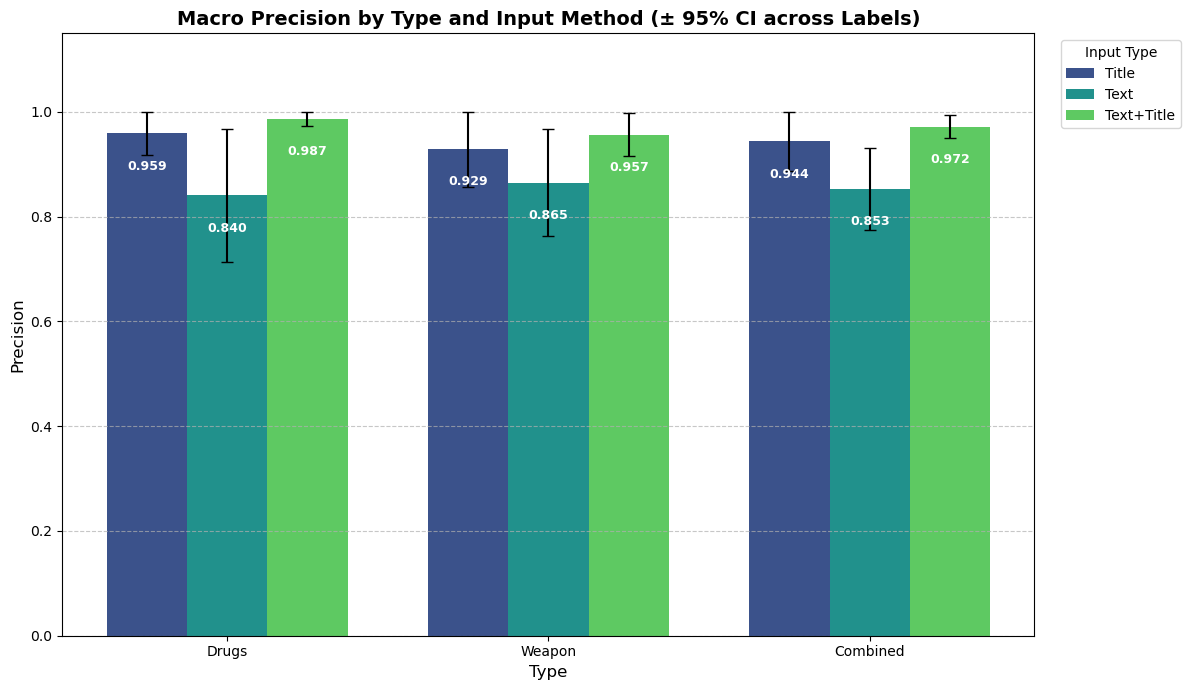

In [9]:
all_metrics = []

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            
            # Map input type to Hebrew-friendly names
            input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
            
            all_metrics.append({
                'Type': TYPE.capitalize(),
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            })

metrics_df = pd.DataFrame(all_metrics)

# Calculate overall metrics per Type and Input_Type (mean and 95% CI across all labels)
overall_metrics = metrics_df.groupby(['Type', 'Input_Type']).agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
overall_metrics.columns = ['Type', 'Input_Type', 
                           'Precision_mean', 'Precision_std', 'Precision_n',
                           'Recall_mean', 'Recall_std', 'Recall_n', 
                           'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']

# Calculate 95% CI
overall_metrics['Precision_ci'] = Z_95 * overall_metrics['Precision_std'] / np.sqrt(overall_metrics['Precision_n'].replace(0, 1))
overall_metrics['Recall_ci'] = Z_95 * overall_metrics['Recall_std'] / np.sqrt(overall_metrics['Recall_n'].replace(0, 1))
overall_metrics['F1-Score_ci'] = Z_95 * overall_metrics['F1-Score_std'] / np.sqrt(overall_metrics['F1-Score_n'].replace(0, 1))

# Add Combined (average of drugs and weapon) with 95% CI
combined_metrics = metrics_df.groupby('Input_Type').agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
combined_metrics.columns = ['Input_Type', 
                            'Precision_mean', 'Precision_std', 'Precision_n',
                            'Recall_mean', 'Recall_std', 'Recall_n', 
                            'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']
combined_metrics['Type'] = 'Combined'

# Calculate 95% CI for combined
combined_metrics['Precision_ci'] = Z_95 * combined_metrics['Precision_std'] / np.sqrt(combined_metrics['Precision_n'].replace(0, 1))
combined_metrics['Recall_ci'] = Z_95 * combined_metrics['Recall_std'] / np.sqrt(combined_metrics['Recall_n'].replace(0, 1))
combined_metrics['F1-Score_ci'] = Z_95 * combined_metrics['F1-Score_std'] / np.sqrt(combined_metrics['F1-Score_n'].replace(0, 1))

overall_metrics = pd.concat([overall_metrics, combined_metrics], ignore_index=True)

# Fill NaN with 0
overall_metrics = overall_metrics.fillna(0)

metrics_to_plot = [('F1-Score', 'F1-Score'), ('Recall', 'Recall'), ('Precision', 'Precision')]

# =====================
# 3 Graphs: Types on X-axis, Input Types as legend, with 95% CI error bars
# =====================
for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(12, 7))
    
    # Prepare data for plotting with error bars
    type_order = ['Drugs', 'Weapon', 'Combined']
    input_order = ['Title', 'Text', 'Text+Title']
    x = np.arange(len(type_order))
    width = 0.25
    
    colors = sns.color_palette('viridis', 3)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for t in type_order:
            row = overall_metrics[(overall_metrics['Type'] == t) & (overall_metrics['Input_Type'] == input_type)]
            mean_val = row[f'{metric_col}_mean'].values[0] if len(row) > 0 else 0
            ci_val = row[f'{metric_col}_ci'].values[0] if len(row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i], 
                       yerr=cis, capsize=4, error_kw={'linewidth': 1.5})
        
        # Add value labels inside bars
        for j, (bar, mean_val) in enumerate(zip(bars, means)):
            if mean_val > 0.15:
                plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                            ha='center', va='top', fontsize=9, fontweight='bold', color='white')
            else:
                plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val + cis[j] + 0.02),
                            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    
    plt.xlabel('Type', fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.title(f'Macro {metric_name} by Type and Input Method (± 95% CI across Labels)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, type_order)
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Micro Comparison

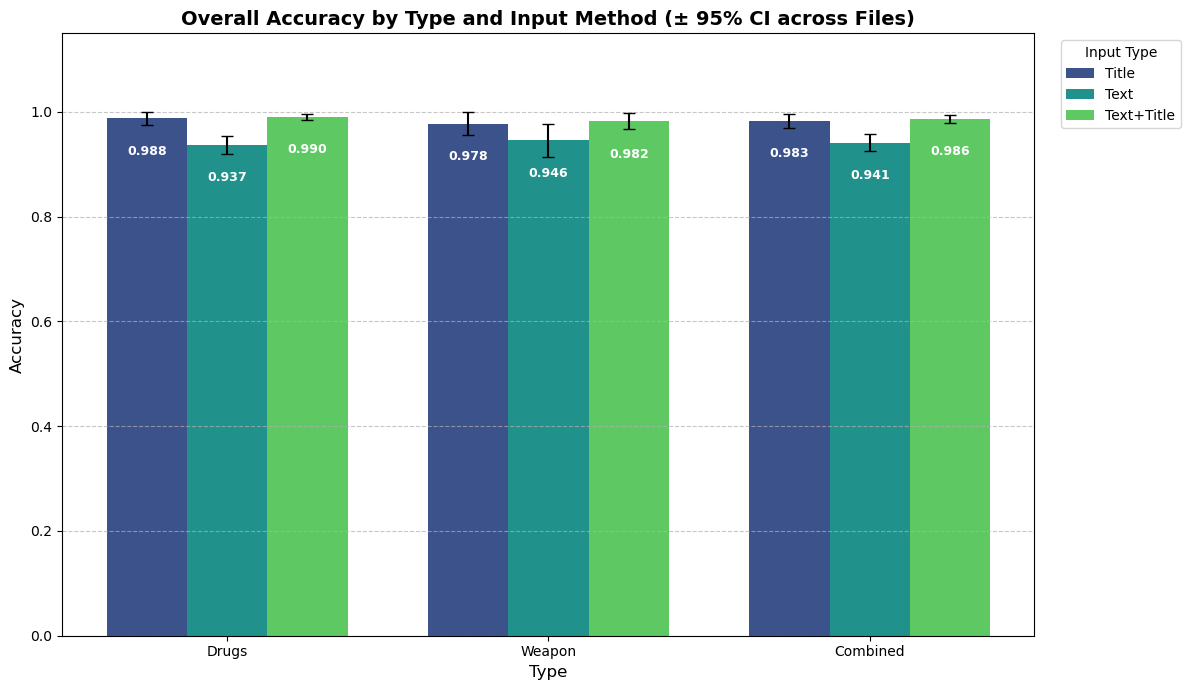

In [10]:
accuracy_data = []

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    # Get file info to calculate per-file accuracy for CI
    path = os.path.join(RESULTS_PATH, TYPE, "only_title")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Calculate OVERALL accuracy
        overall_acc = accuracy_score(y_true, y_pred)
        
        # Calculate per-file accuracies for error bars
        file_accuracies = []
        start_idx = 0
        for file in files:
            case = 'only_title' if col == 'title_results' else ('only_text' if col == 'text_results' else 'text_and_title')
            file_path = os.path.join(RESULTS_PATH, TYPE, case, file)
            if os.path.exists(file_path):
                file_df = pd.read_csv(file_path)
                file_len = len(file_df)
                if file_len > 0:
                    file_y_true = y_true.iloc[start_idx:start_idx + file_len]
                    file_y_pred = y_pred.iloc[start_idx:start_idx + file_len]
                    if len(file_y_true) > 0:
                        file_acc = accuracy_score(file_y_true, file_y_pred)
                        file_accuracies.append(file_acc)
                start_idx += file_len
        
        # Calculate 95% CI
        n = len(file_accuracies)
        acc_std = np.std(file_accuracies) if n > 1 else 0
        acc_ci = Z_95 * acc_std / np.sqrt(n) if n > 0 else 0
        
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        
        accuracy_data.append({
            'Type': TYPE.capitalize(),
            'Input_Type': input_name,
            'Accuracy_mean': overall_acc,
            'Accuracy_std': acc_std,
            'Accuracy_n': n,
            'Accuracy_ci': acc_ci
        })

accuracy_df = pd.DataFrame(accuracy_data)

# Add Combined (average of drugs and weapon) with 95% CI
combined_acc = accuracy_df.groupby('Input_Type').agg({
    'Accuracy_mean': 'mean',
    'Accuracy_std': 'mean',
    'Accuracy_n': 'sum'
}).reset_index()
combined_acc['Accuracy_ci'] = Z_95 * combined_acc['Accuracy_std'] / np.sqrt(combined_acc['Accuracy_n'].replace(0, 1))
combined_acc['Type'] = 'Combined'
accuracy_df = pd.concat([accuracy_df, combined_acc], ignore_index=True)

# =====================
# Single plot: Types on X-axis, Input Types as legend, with 95% CI error bars
# =====================
plt.figure(figsize=(12, 7))

type_order = ['Drugs', 'Weapon', 'Combined']
input_order = ['Title', 'Text', 'Text+Title']
x = np.arange(len(type_order))
width = 0.25

colors = sns.color_palette('viridis', 3)

for i, input_type in enumerate(input_order):
    means = []
    cis = []
    for t in type_order:
        row = accuracy_df[(accuracy_df['Type'] == t) & (accuracy_df['Input_Type'] == input_type)]
        mean_val = row['Accuracy_mean'].values[0] if len(row) > 0 else 0
        ci_val = row['Accuracy_ci'].values[0] if len(row) > 0 else 0
        means.append(mean_val)
        # Clip CI so error bars don't exceed [0, 1]
        cis.append(clip_ci(mean_val, ci_val))
    
    bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                   yerr=cis, capsize=4, error_kw={'linewidth': 1.5})
    
    # Add value labels
    for j, (bar, mean_val) in enumerate(zip(bars, means)):
        if mean_val > 0.15:
            plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                        ha='center', va='top', fontsize=9, fontweight='bold', color='white')
        else:
            plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val + cis[j] + 0.02),
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.xlabel('Type', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overall Accuracy by Type and Input Method (± 95% CI across Files)', fontsize=14, fontweight='bold')
plt.xticks(x + width, type_order)
plt.ylim(0, 1.15)
plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Save csv of results

In [109]:
all_stats = []
combined_results = {}  # Store for combined calculation

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    # Store for combined
    combined_results[TYPE] = results_df.copy()
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Overall metrics
        acc = accuracy_score(y_true, y_pred)
        macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        
        # Add overall row
        all_stats.append({
            'Dataset': TYPE.capitalize(),
            'Input_Type': input_name,
            'Label': 'OVERALL',
            'Accuracy': acc,
            'Precision': macro_precision,
            'Recall': macro_recall,
            'F1-Score': macro_f1,
            'Micro-F1': micro_f1,
            'Weighted-F1': weighted_f1,
            'Support': len(y_true)
        })
        
        # Per-label metrics
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            support = (y_true == label).sum()
            
            all_stats.append({
                'Dataset': TYPE.capitalize(),
                'Input_Type': input_name,
                'Label': label,
                'Accuracy': None,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1,
                'Micro-F1': None,
                'Weighted-F1': None,
                'Support': support
            })

# =====================
# COMBINED (Drugs + Weapon) Statistics
# =====================
combined_df = pd.concat([combined_results['drugs'], combined_results['weapon']], ignore_index=True)
all_unique_labels = sorted(combined_df['label'].unique())

for col in prediction_columns:
    y_true = combined_df['label']
    y_pred = combined_df[col]
    
    # Overall metrics
    acc = accuracy_score(y_true, y_pred)
    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
    
    # Add overall row for combined
    all_stats.append({
        'Dataset': 'Combined',
        'Input_Type': input_name,
        'Label': 'OVERALL',
        'Accuracy': acc,
        'Precision': macro_precision,
        'Recall': macro_recall,
        'F1-Score': macro_f1,
        'Micro-F1': micro_f1,
        'Weighted-F1': weighted_f1,
        'Support': len(y_true)
    })
    
    # Per-label metrics for combined
    for label in all_unique_labels:
        label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        support = (y_true == label).sum()
        
        all_stats.append({
            'Dataset': 'Combined',
            'Input_Type': input_name,
            'Label': label,
            'Accuracy': None,
            'Precision': label_precision,
            'Recall': label_recall,
            'F1-Score': label_f1,
            'Micro-F1': None,
            'Weighted-F1': None,
            'Support': support
        })

# Create DataFrame
stats_df = pd.DataFrame(all_stats)

# Reorder columns
stats_df = stats_df[['Dataset', 'Input_Type', 'Label', 'Accuracy', 'Precision', 'Recall', 
                     'F1-Score', 'Micro-F1', 'Weighted-F1', 'Support']]

# Save to CSV
output_path = os.path.join(RESULTS_PATH, 'all_statistics_summary.csv')
stats_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Statistics saved to: {output_path}")
print(f"Total rows: {len(stats_df)}")

# Display the table
print("\n" + "=" * 100)
print("OVERALL STATISTICS (per Dataset and Input Type)")
print("=" * 100)
overall_stats = stats_df[stats_df['Label'] == 'OVERALL'][['Dataset', 'Input_Type', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Support']]
print(overall_stats.to_string(index=False))

# Also create a summary pivot table
print("\n" + "=" * 100)
print("ACCURACY SUMMARY TABLE")
print("=" * 100)
accuracy_pivot = stats_df[stats_df['Label'] == 'OVERALL'].pivot(index='Dataset', columns='Input_Type', values='Accuracy')
accuracy_pivot = accuracy_pivot[['Title', 'Text', 'Text+Title']]
print(accuracy_pivot.round(4))

print("\n" + "=" * 100)
print("F1-SCORE SUMMARY TABLE")
print("=" * 100)
f1_pivot = stats_df[stats_df['Label'] == 'OVERALL'].pivot(index='Dataset', columns='Input_Type', values='F1-Score')
f1_pivot = f1_pivot[['Title', 'Text', 'Text+Title']]
print(f1_pivot.round(4))

# Show full dataframe
stats_df

Statistics saved to: ..\results\all_statistics_summary.csv
Total rows: 63

OVERALL STATISTICS (per Dataset and Input Type)
 Dataset Input_Type  Accuracy  Precision   Recall  F1-Score  Support
   Drugs      Title  0.987534   0.958906 0.987086  0.971257     1845
   Drugs       Text  0.937127   0.840468 0.881821  0.859541     1845
   Drugs Text+Title  0.990244   0.986668 0.985097  0.985707     1845
  Weapon      Title  0.977823   0.928654 0.955644  0.936726     1488
  Weapon       Text  0.945565   0.864991 0.918216  0.886154     1488
  Weapon Text+Title  0.981855   0.956655 0.973994  0.964428     1488
Combined      Title  0.983198   0.944838 0.974394  0.956608     3333
Combined       Text  0.940894   0.851781 0.897080  0.871976     3333
Combined Text+Title  0.986499   0.973397 0.980800  0.977049     3333

ACCURACY SUMMARY TABLE
Input_Type   Title    Text  Text+Title
Dataset                               
Combined    0.9832  0.9409      0.9865
Drugs       0.9875  0.9371      0.9902
Weapon 

,Dataset,Input_Type,Label,Accuracy,Precision,Recall,F1-Score,Micro-F1,Weighted-F1,Support
0,Drugs,Title,OVERALL,0.987534,0.958906,0.987086,0.971257,0.987534,0.987787,1845
1,Drugs,Title,דיון והכרעה,NaN,1.000000,0.995331,0.997660,NaN,NaN,1071
2,Drugs,Title,טיעוני הצדדים,NaN,1.000000,0.938017,0.968017,NaN,NaN,242
3,Drugs,Title,מידע אחר,NaN,0.958904,1.000000,0.979021,NaN,NaN,70
4,Drugs,Title,עובדות המקרה,NaN,0.975089,0.989170,0.982079,NaN,NaN,277
...,...,...,...,...,...,...,...,...,...,...
58,Combined,Text+Title,טיעוני הצדדים,NaN,0.977876,0.977876,0.977876,NaN,NaN,452
59,Combined,Text+Title,מידע אחר,NaN,1.000000,1.000000,1.000000,NaN,NaN,116
60,Combined,Text+Title,עובדות המקרה,NaN,0.963134,0.965358,0.964245,NaN,NaN,433
61,Combined,Text+Title,ראיות לעונש,NaN,0.930000,0.948980,0.939394,NaN,NaN,98


In [112]:
# Add this as a new cell after "## Save csv of results"

from sklearn.metrics import classification_report

# =====================
# Classification Reports
# =====================
print("=" * 100)
print("CLASSIFICATION REPORTS")
print("=" * 100)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    print(f"\n{'='*50}")
    print(f"DATASET: {TYPE.upper()}")
    print(f"{'='*50}")
    
    for col in prediction_columns:
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        print(f"\n--- Input Type: {input_name} ---")
        print(classification_report(y_true, y_pred, labels=unique_labels, zero_division=0))

# =====================
# Combined Classification Report
# =====================
print(f"\n{'='*50}")
print("DATASET: COMBINED (Drugs + Weapon)")
print(f"{'='*50}")

combined_df = pd.concat([
    pd.read_csv(os.path.join(RESULTS_PATH,t, 'all_results.csv')) for t in TYPES
], ignore_index=True)

combined_df = combined_df.dropna(subset=['label'])
combined_df[prediction_columns] = combined_df[prediction_columns].fillna('MISSING')
combined_df['label'] = combined_df['label'].astype(str)
for col in prediction_columns:
    combined_df[col] = combined_df[col].astype(str)

all_unique_labels = sorted(combined_df['label'].unique())

for col in prediction_columns:
    input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
    y_true = combined_df['label']
    y_pred = combined_df[col]
    
    print(f"\n--- Input Type: {input_name} ---")
    print(classification_report(y_true, y_pred, labels=all_unique_labels, zero_division=0))

# =====================
# Save Classification Reports to CSV
# =====================
all_reports = []

for TYPE in TYPES + ['combined']:
    if TYPE == 'combined':
        df = combined_df
        labels = all_unique_labels
    else:
        df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
        df = df.dropna(subset=['label'])
        df[prediction_columns] = df[prediction_columns].fillna('MISSING')
        df['label'] = df['label'].astype(str)
        for col in prediction_columns:
            df[col] = df[col].astype(str)
        labels = sorted(df['label'].unique())
    
    for col in prediction_columns:
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        y_true = df['label']
        y_pred = df[col]
        
        report_dict = classification_report(y_true, y_pred, labels=labels, 
                                            output_dict=True, zero_division=0)
        
        for label, metrics in report_dict.items():
            if isinstance(metrics, dict):
                all_reports.append({
                    'Dataset': TYPE.capitalize(),
                    'Input_Type': input_name,
                    'Label': label,
                    'Precision': metrics.get('precision', None),
                    'Recall': metrics.get('recall', None),
                    'F1-Score': metrics.get('f1-score', None),
                    'Support': metrics.get('support', None)
                })

reports_df = pd.DataFrame(all_reports)
reports_path = os.path.join(RESULTS_PATH, 'classification_reports.csv')
reports_df.to_csv(reports_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Classification reports saved to: {reports_path}")

CLASSIFICATION REPORTS

DATASET: DRUGS

--- Input Type: Title ---
                  precision    recall  f1-score   support

     דיון והכרעה       1.00      1.00      1.00      1071
   טיעוני הצדדים       1.00      0.94      0.97       242
        מידע אחר       0.96      1.00      0.98        70
    עובדות המקרה       0.98      0.99      0.98       277
     ראיות לעונש       0.82      1.00      0.90        59
תסקיר שירות מבחן       1.00      1.00      1.00       126

        accuracy                           0.99      1845
       macro avg       0.96      0.99      0.97      1845
    weighted avg       0.99      0.99      0.99      1845


--- Input Type: Text ---
                  precision    recall  f1-score   support

     דיון והכרעה       1.00      0.97      0.98      1071
   טיעוני הצדדים       0.86      0.86      0.86       242
        מידע אחר       0.84      1.00      0.92        70
    עובדות המקרה       0.94      0.94      0.94       277
     ראיות לעונש       0.54      0